# Group LSOA data

To prevent jitter in age-admissions fits.

In [1]:
import os
import polars as pl
import numpy as np

from scipy.optimize import minimize
import statsmodels.api as sm  # for linear regression

import matplotlib.pyplot as plt

## Load data

Patient demographics by MSOA:

In [2]:
path_to_msoa_stats = os.path.join('data', 'msoa_cleaned.csv')

df_stats = pl.read_csv(path_to_msoa_stats)

In [3]:
df_stats.head()

MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,prop_bad health,MSOA11CD,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion
str,f64,f64,i64,str,i64,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64
"""Adur 001""",14.333333,16.924833,8815,"""E""",6799,1251,474,0.79763,0.146762,0.055608,"""E02006534""",0.0559,0.0528,0.0422,0.7872,0.062
"""Adur 002""",7.333333,6.4704,7263,"""E""",5537,838,259,0.83464,0.126319,0.039041,"""E02006535""",0.0578,0.0774,0.0492,0.7467,0.0692
"""Adur 003""",9.333333,13.7334,7354,"""E""",5820,969,311,0.819718,0.136479,0.043803,"""E02006536""",0.0609,0.0582,0.0421,0.7729,0.0661
"""Adur 004""",21.0,26.199857,10582,"""E""",7872,1546,709,0.777328,0.152661,0.070011,"""E02006537""",0.0465,0.0438,0.0367,0.8091,0.0638
"""Adur 005""",13.666667,11.7948,9059,"""E""",7106,1081,339,0.833451,0.126789,0.039761,"""E02006538""",0.0597,0.067,0.0425,0.7643,0.0662


Check sum of admissions for Welsh areas:

In [4]:
df_stats.filter(df_stats['country'] == 'W')['admissions'].sum()

0.0

Welsh data is always zero so remove it.

In [5]:
df_stats = df_stats.filter(df_stats['country'] != 'W')

Recalculate total numbers of patients:

In [6]:
df_stats = df_stats.with_columns((pl.col('good_health') + pl.col('fair health') + pl.col('bad health')).alias('total_health'))

In [7]:
df_stats.head()

MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,prop_bad health,MSOA11CD,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion,total_health
str,f64,f64,i64,str,i64,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64,i64
"""Adur 001""",14.333333,16.924833,8815,"""E""",6799,1251,474,0.79763,0.146762,0.055608,"""E02006534""",0.0559,0.0528,0.0422,0.7872,0.062,8524
"""Adur 002""",7.333333,6.4704,7263,"""E""",5537,838,259,0.83464,0.126319,0.039041,"""E02006535""",0.0578,0.0774,0.0492,0.7467,0.0692,6634
"""Adur 003""",9.333333,13.7334,7354,"""E""",5820,969,311,0.819718,0.136479,0.043803,"""E02006536""",0.0609,0.0582,0.0421,0.7729,0.0661,7100
"""Adur 004""",21.0,26.199857,10582,"""E""",7872,1546,709,0.777328,0.152661,0.070011,"""E02006537""",0.0465,0.0438,0.0367,0.8091,0.0638,10127
"""Adur 005""",13.666667,11.7948,9059,"""E""",7106,1081,339,0.833451,0.126789,0.039761,"""E02006538""",0.0597,0.067,0.0425,0.7643,0.0662,8526


Pick out column names for the health and age proportions:

In [8]:
health_numbers = ['good_health', 'fair health', 'bad health']
props_health = ['prop_good_health', 'prop_fair health', 'prop_bad health']
props_age = [
    'age_less65_proportion', 'age_65_proportion', 'age_70_proportion',
    'age_75_proportion', 'age_over80_proportion'
]

Calculate numbers of patients in each age band:

In [9]:
age_numbers = []

for col in props_age:
    new_col = col.replace('_proportion', '')
    age_numbers.append(new_col)
    df_stats = df_stats.with_columns((pl.col(col) * pl.col('total_health')).alias(new_col))

In [10]:
df_stats[['total_health'] + props_age + age_numbers].head()

total_health,age_less65_proportion,age_65_proportion,age_70_proportion,age_75_proportion,age_over80_proportion,age_less65,age_65,age_70,age_75,age_over80
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
8524,0.7872,0.0559,0.0528,0.0422,0.062,6710.0928,476.4916,450.0672,359.7128,528.488
6634,0.7467,0.0578,0.0774,0.0492,0.0692,4953.6078,383.4452,513.4716,326.3928,459.0728
7100,0.7729,0.0609,0.0582,0.0421,0.0661,5487.59,432.39,413.22,298.91,469.31
10127,0.8091,0.0465,0.0438,0.0367,0.0638,8193.7557,470.9055,443.5626,371.6609,646.1026
8526,0.7643,0.0597,0.067,0.0425,0.0662,6516.4218,509.0022,571.242,362.355,564.4212


## Set up bins for IMD scores

Use quantiles so that each bin contains 10% of the MSOA (to match plot notebook).

The resulting dictionary has keys for which quantile it is and values for the left side (smaller, minimum value in bin) of the IMD bin.

In [11]:
dict_quantiles = {}

for q in np.arange(0.0, 1.01, 0.2):
    v = df_stats['IMD2019Score'].quantile(q)
    # Flip the ranking because lower rank (more deprived) should be for
    # higher IMD scores (more deprived).
    q_store = 1.0 - q
    dict_quantiles[round(q_store, 1)] = round(v, 5)

In [12]:
dict_quantiles

{1.0: 2.2122,
 0.8: 10.369,
 0.6: 15.2564,
 0.4: 21.81475,
 0.2: 31.84075,
 0.0: 87.02675}

Pick out just the values for the left edges of the bins:

In [13]:
imd_bin_left_edges = {}
for k in list(dict_quantiles.keys())[:-1]:
    imd_bin_left_edges[k] = dict_quantiles[k]

In [14]:
imd_bin_left_edges

{1.0: 2.2122, 0.8: 10.369, 0.6: 15.2564, 0.4: 21.81475, 0.2: 31.84075}

Place MSOA into these bins:

In [18]:
# Make columns for the results with a placeholder value:
# df_stats = df_stats.with_columns(pl.lit(0).alias('imd_bin_min'))
# df_stats = df_stats.with_columns(pl.lit(0).alias('imd_bin_max'))
df_stats = df_stats.with_columns(pl.lit(0.0).alias('depriv_quantile_min'))
df_stats = df_stats.with_columns(pl.lit(0.0).alias('depriv_quantile_max'))

for q, quantile in enumerate(list(dict_quantiles.keys())[:-1]):
    # Pick out the bin edges:
    qmin = list(dict_quantiles.keys())[q+1]
    q0 = dict_quantiles[quantile]
    q1 = dict_quantiles[qmin]
    # Find a mask for the demographic data that contains
    # only MSOA with IMD scores in this bin.
    mask = (df_stats['IMD2019Score'] >= q0) & (df_stats['IMD2019Score'] < q1)
    if q == len(dict_quantiles) - 2:
        # Also allow values at the right edge of the final bin.
        mask = mask | (df_stats['IMD2019Score'] == q1)

    # Update the bin min/max values for these rows:
    df_stats = df_stats.with_columns(
        pl.when((mask))
        .then(qmin)         # replace with bin min
        .otherwise(pl.col('depriv_quantile_min'))  # otherwise keep the existing value
        .name.keep()
    )
    df_stats = df_stats.with_columns(
        pl.when((mask))
        .then(quantile)         # replace with bin min
        .otherwise(pl.col('depriv_quantile_max'))  # otherwise keep the existing value
        .name.keep()
    )

Check that data was binned correctly:

In [19]:
df_stats[['IMD2019Score', 'depriv_quantile_min', 'depriv_quantile_max']]

IMD2019Score,depriv_quantile_min,depriv_quantile_max
f64,f64,f64
16.924833,0.4,0.6
6.4704,0.8,1.0
13.7334,0.6,0.8
26.199857,0.2,0.4
11.7948,0.6,0.8
…,…,…
3.25925,0.8,1.0
7.29475,0.8,1.0
12.117,0.6,0.8


## Stats checks

In [20]:
df_stats.columns

['MSOA',
 'admissions',
 'IMD2019Score',
 'All persons',
 'country',
 'good_health',
 'fair health',
 'bad health',
 'prop_good_health',
 'prop_fair health',
 'prop_bad health',
 'MSOA11CD',
 'age_65_proportion',
 'age_70_proportion',
 'age_75_proportion',
 'age_less65_proportion',
 'age_over80_proportion',
 'total_health',
 'age_less65',
 'age_65',
 'age_70',
 'age_75',
 'age_over80',
 'imd_bin_min',
 'imd_bin_max',
 'depriv_quantile_min',
 'depriv_quantile_max']

In [23]:
df_stats = df_stats.with_columns(pl.Series('admissions_prop', df_stats['admissions'] / df_stats['All persons']))

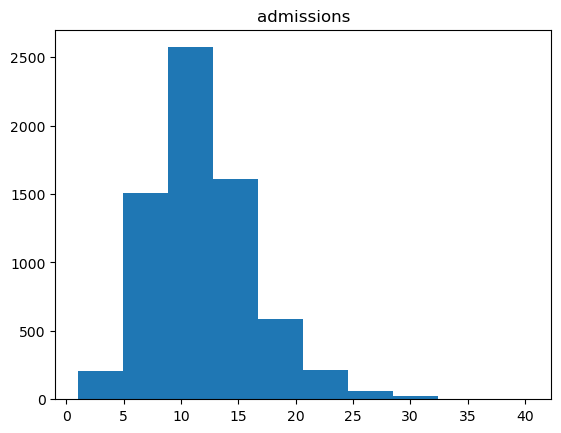

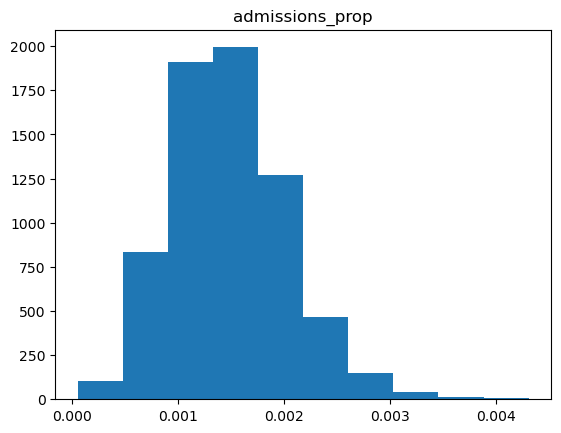

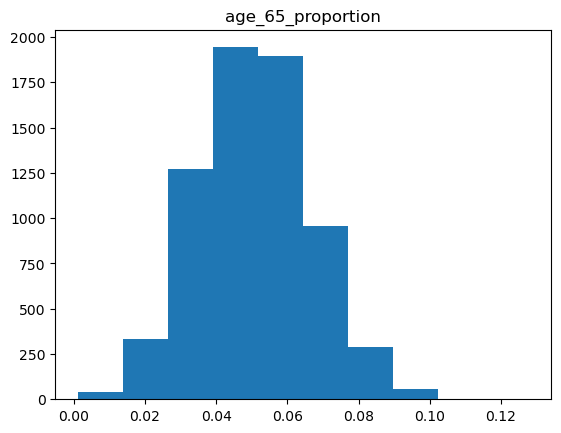

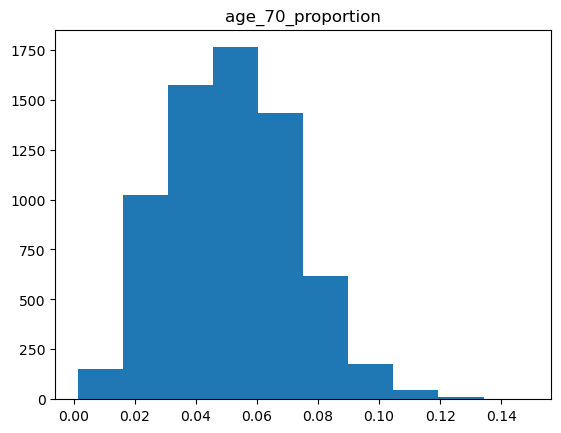

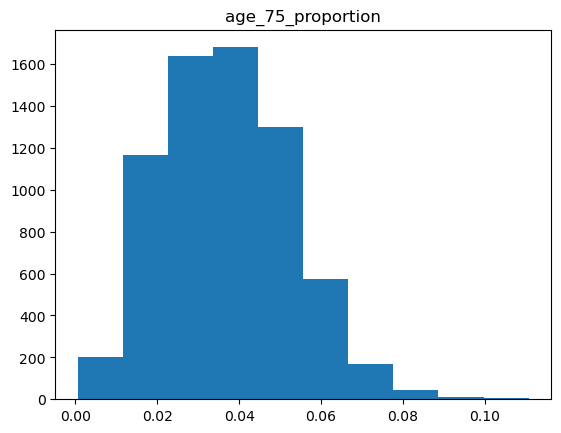

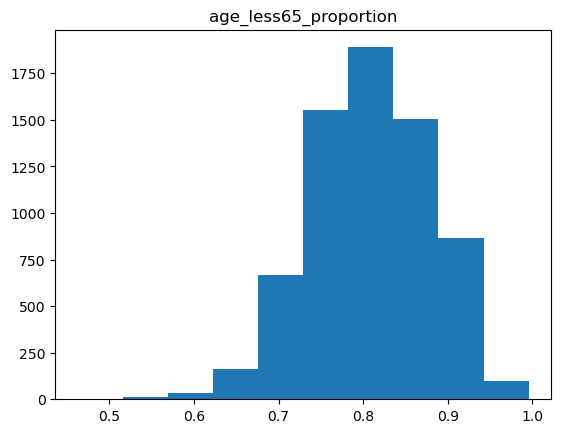

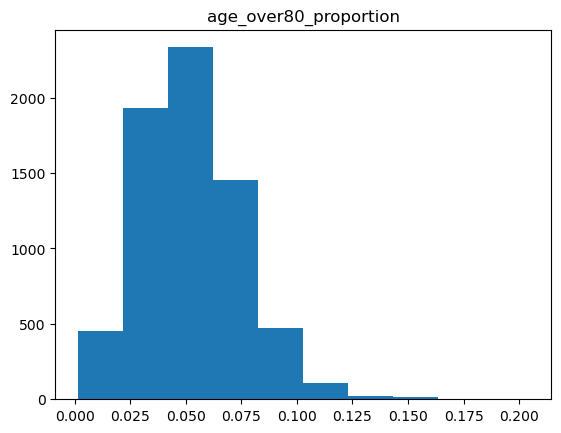

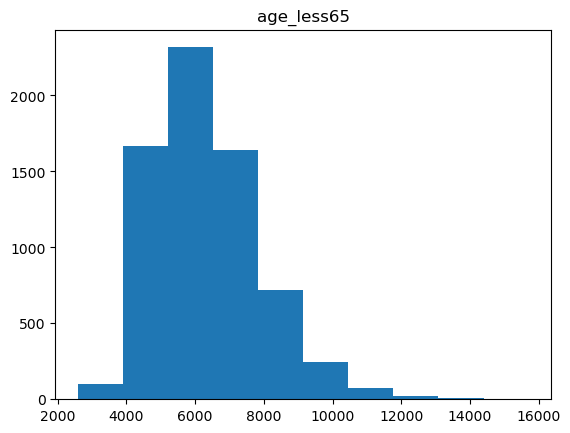

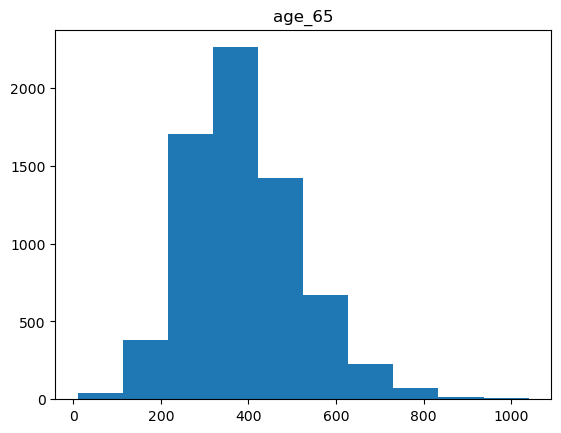

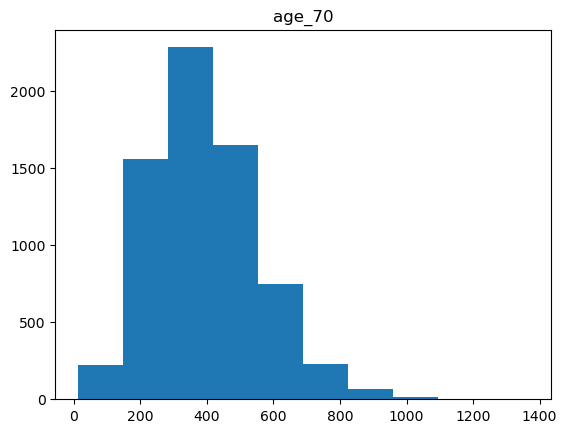

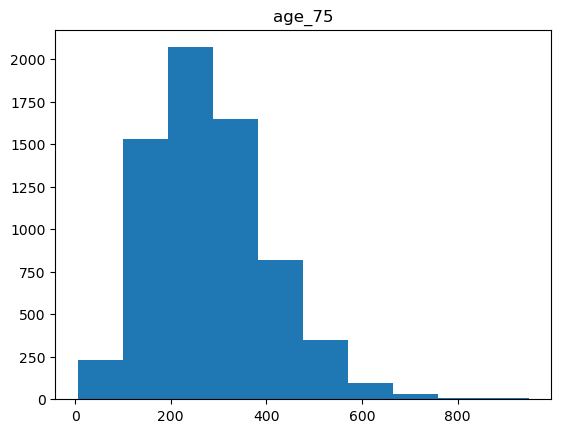

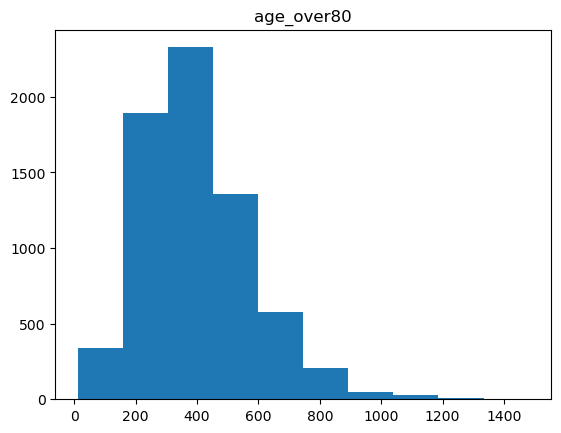

In [24]:
cols_to_check = [
    'admissions',
    'admissions_prop',
    'age_65_proportion',
    'age_70_proportion',
    'age_75_proportion',
    'age_less65_proportion',
    'age_over80_proportion',
    'age_less65',
    'age_65',
    'age_70',
    'age_75',
    'age_over80',
]

for col in cols_to_check:
    fig, ax = plt.subplots()
    ax.hist(df_stats[col])
    ax.set_title(col)
    plt.show()

Are there any LSOA that have similar proportions of age bands but different total numbers and so different admissions numbers?

In [32]:
df = pl.concat((
    df_stats[cols_to_check].min(),
    df_stats[cols_to_check].max(),
    df_stats[cols_to_check].mean(),
    df_stats[cols_to_check].std(),
))

df = df.with_columns(pl.Series('type', ['min', 'max', 'mean', 'std']))

display(df)

admissions,admissions_prop,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion,age_less65,age_65,age_70,age_75,age_over80,type
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
1.0,0.000053,0.0011,0.0013,0.0006,0.4627,0.0014,2584.8576,10.1816,11.7895,5.5536,11.226,"""min"""
40.333333,0.004304,0.1278,0.149,0.1107,0.9955,0.2043,15706.2962,1039.7744,1367.2624,948.5064,1480.5704,"""max"""
11.923122,0.001482,0.050779,0.05164,0.036904,0.80842,0.052259,6340.851989,389.62438,394.570993,281.902232,400.174612,"""mean"""
4.520005,0.000544,0.015745,0.020377,0.015589,0.070685,0.022518,1557.202958,129.431773,161.373431,122.858779,179.217669,"""std"""


In [35]:
cols_to_check = [
    'admissions',
    'admissions_prop',
    'age_65_proportion',
    'age_70_proportion',
    'age_75_proportion',
    'age_less65_proportion',
    'age_over80_proportion',
    'age_less65',
    'age_65',
    'age_70',
    'age_75',
    'age_over80',
]

print(np.histogram(df_stats['age_less65_proportion'], bins=np.arange(0.6, 1.01, 0.1)))
print(np.histogram(df_stats['age_65_proportion'], bins=np.arange(0.0, 0.1001, 0.02)))
print(np.histogram(df_stats['age_70_proportion'], bins=np.arange(0.0, 0.1001, 0.02)))
print(np.histogram(df_stats['age_75_proportion'], bins=np.arange(0.0, 0.1001, 0.02)))
print(np.histogram(df_stats['age_over80_proportion'], bins=np.arange(0.0, 0.1001, 0.02)))

(array([ 383, 2601, 3071,  701]), array([0.6, 0.7, 0.8, 0.9, 1. ]))
(array([ 108, 1629, 3178, 1635,  231]), array([0.  , 0.02, 0.04, 0.06, 0.08, 0.1 ]))
(array([ 326, 1742, 2401, 1736,  501]), array([0.  , 0.02, 0.04, 0.06, 0.08, 0.1 ]))
(array([1023, 2955, 2284,  481,   42]), array([0.  , 0.02, 0.04, 0.06, 0.08, 0.1 ]))
(array([ 340, 1825, 2331, 1565,  545]), array([0.  , 0.02, 0.04, 0.06, 0.08, 0.1 ]))


In [41]:
def make_bin_mids(bins, dummy=42000):
    bin_mids = np.array(bins)[:-1] + 0.5 * np.diff(bins)
    bin_mids = np.concatenate(([-dummy], bin_mids, [dummy]))
    return bin_mids

In [42]:
def bin_values(vals, bins, bin_mids):
    inds = np.digitize(vals, bins)
    bin_mids_here = bin_mids[inds]
    return bin_mids_here

In [77]:
bin_dicts = {
    'age_less65_proportion': {
        'bins': np.arange(0.6, 1.01, 0.1),
    },
    'age_65_proportion': {
        'bins': np.arange(0.0, 0.1001, 0.02),
    },
    'age_70_proportion': {
        'bins': np.arange(0.0, 0.1001, 0.02),
    },
    'age_75_proportion': {
        'bins': np.arange(0.0, 0.1001, 0.02),
    },
    'age_over80_proportion': {
        'bins': np.arange(0.0, 0.1001, 0.02),
    },
}

for prop, bin_dict in bin_dicts.items():
    bin_dicts[prop]['bin_mids'] = make_bin_mids(bin_dict['bins'])
    new_col_name = prop.replace('age_', 'bin_mids_')
    bin_dicts[prop]['column'] = new_col_name

bin_mid_cols = [b['column'] for b in list(bin_dicts.values())]

In [74]:
bin_dicts

{'age_less65_proportion': {'bins': array([0.6, 0.7, 0.8, 0.9, 1. ]),
  'bin_mids': array([-4.2e+04,  6.5e-01,  7.5e-01,  8.5e-01,  9.5e-01,  4.2e+04]),
  'column': 'bin_mids_less65_proportion'},
 'age_65_proportion': {'bins': array([0.  , 0.02, 0.04, 0.06, 0.08, 0.1 ]),
  'bin_mids': array([-4.2e+04,  1.0e-02,  3.0e-02,  5.0e-02,  7.0e-02,  9.0e-02,
          4.2e+04]),
  'column': 'bin_mids_65_proportion'},
 'age_70_proportion': {'bins': array([0.  , 0.02, 0.04, 0.06, 0.08, 0.1 ]),
  'bin_mids': array([-4.2e+04,  1.0e-02,  3.0e-02,  5.0e-02,  7.0e-02,  9.0e-02,
          4.2e+04]),
  'column': 'bin_mids_70_proportion'},
 'age_75_proportion': {'bins': array([0.  , 0.02, 0.04, 0.06, 0.08, 0.1 ]),
  'bin_mids': array([-4.2e+04,  1.0e-02,  3.0e-02,  5.0e-02,  7.0e-02,  9.0e-02,
          4.2e+04]),
  'column': 'bin_mids_75_proportion'},
 'age_over80_proportion': {'bins': array([0.  , 0.02, 0.04, 0.06, 0.08, 0.1 ]),
  'bin_mids': array([-4.2e+04,  1.0e-02,  3.0e-02,  5.0e-02,  7.0e-02,  9.

In [78]:
bin_mid_cols

['bin_mids_less65_proportion',
 'bin_mids_65_proportion',
 'bin_mids_70_proportion',
 'bin_mids_75_proportion',
 'bin_mids_over80_proportion']

In [75]:
for prop, bin_dict in bin_dicts.items():
    df_stats = df_stats.with_columns(pl.Series(bin_dict['column'], bin_values(df_stats[prop], bin_dict['bins'], bin_dict['bin_mids'])))

In [76]:
df_stats[[c for c in df_stats.columns if 'proportion' in c]]

age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion,bin_mids_less65_proportion,bin_mids_65_proportion,bin_mids_70_proportion,bin_mids_75_proportion,bin_mids_over80_proportion
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0559,0.0528,0.0422,0.7872,0.062,0.75,0.05,0.05,0.05,0.07
0.0578,0.0774,0.0492,0.7467,0.0692,0.75,0.05,0.07,0.05,0.07
0.0609,0.0582,0.0421,0.7729,0.0661,0.75,0.07,0.05,0.05,0.07
0.0465,0.0438,0.0367,0.8091,0.0638,0.85,0.05,0.05,0.03,0.07
0.0597,0.067,0.0425,0.7643,0.0662,0.75,0.05,0.07,0.05,0.07
…,…,…,…,…,…,…,…,…,…
0.0595,0.0743,0.0555,0.7301,0.0806,0.75,0.05,0.07,0.05,0.09
0.0509,0.0456,0.0377,0.8052,0.0606,0.85,0.05,0.05,0.03,0.07
0.0594,0.0675,0.046,0.7629,0.0641,0.75,0.05,0.07,0.05,0.07


Find each combination of bins:

In [ ]:
bin_combos = []


In [53]:
from itertools import product

In [61]:
all_bin_mid_combos = list(product(*[b['bin_mids'] for b in list(bin_dicts.values())]))

In [116]:
len(all_bin_mid_combos)

14406

In [117]:
list_series_bin_mid_combo_n = []

i = 0
for bin_mid_combo in all_bin_mid_combos:
    bool_match = (df_stats[bin_mid_cols].to_numpy() == bin_mid_combo).all(axis=1)
    n_match = len(bool_match[bool_match == True])
    if n_match > 0:
        s = pl.DataFrame(pl.Series(f'{i}', list(bin_mid_combo) + [n_match]))
        list_series_bin_mid_combo_n.append(s)
        i += 1

In [118]:
df_bin_mid_combo_n = pl.concat(list_series_bin_mid_combo_n, how='horizontal')

label_series = pl.DataFrame(pl.Series('label', bin_mid_cols + ['n_combo']))
df_bin_mid_combo_n = pl.concat((label_series, df_bin_mid_combo_n), how='horizontal')

df_bin_mid_combo_n = df_bin_mid_combo_n.transpose(column_names='label')

df_bin_mid_combo_n = df_bin_mid_combo_n.with_columns(pl.Series('combo', range(len(df_bin_mid_combo_n))))

In [125]:
df_bin_mid_combo_n.sort('n_combo')

bin_mids_less65_proportion,bin_mids_65_proportion,bin_mids_70_proportion,bin_mids_75_proportion,bin_mids_over80_proportion,n_combo,combo
f64,f64,f64,f64,f64,f64,i64
-42000.0,0.07,0.09,0.09,42000.0,1.0,0
-42000.0,0.07,42000.0,0.07,42000.0,1.0,1
-42000.0,0.09,0.09,0.09,42000.0,1.0,3
-42000.0,0.09,42000.0,0.07,42000.0,1.0,4
0.65,0.05,0.09,0.07,0.09,1.0,10
…,…,…,…,…,…,…
0.75,0.07,0.07,0.05,0.05,288.0,83
0.85,0.05,0.05,0.03,0.03,327.0,127
0.85,0.03,0.03,0.03,0.03,453.0,111


In [140]:
quantile_min_list = sorted(df_stats['depriv_quantile_min'].unique())

quantile_min_list

[0.0, 0.2, 0.4, 0.6, 0.8]

In [143]:
colours = plt.get_cmap('viridis')(np.linspace(0.0, 1.0, len(quantile_min_list)))

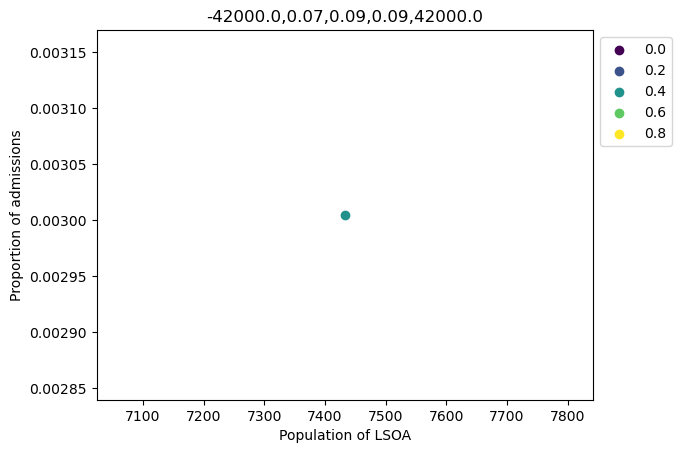

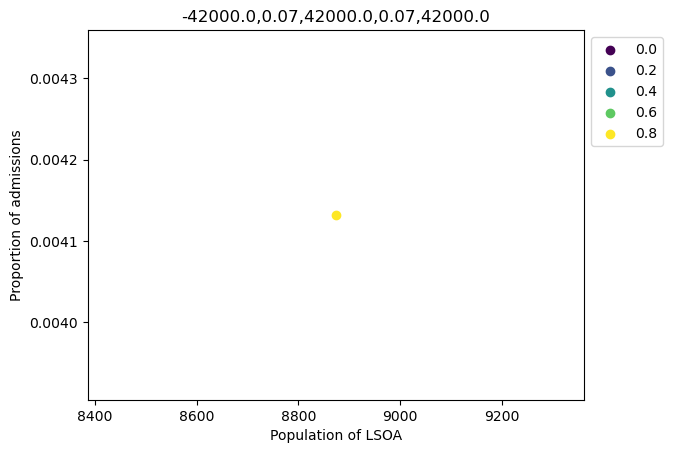

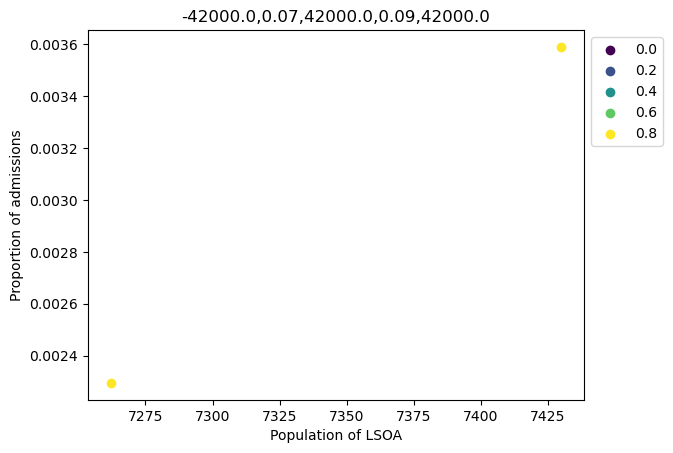

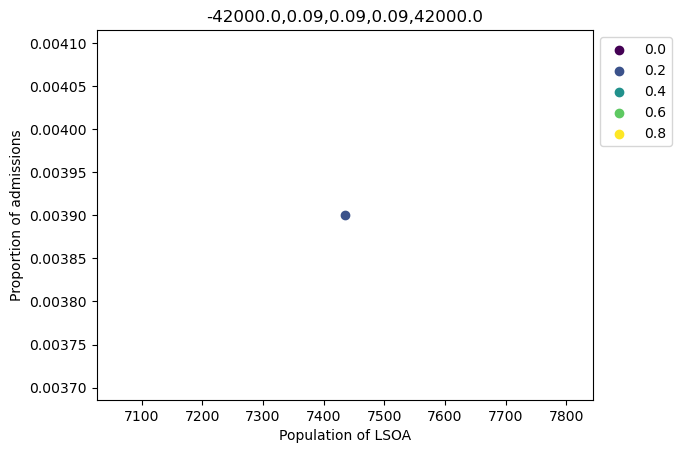

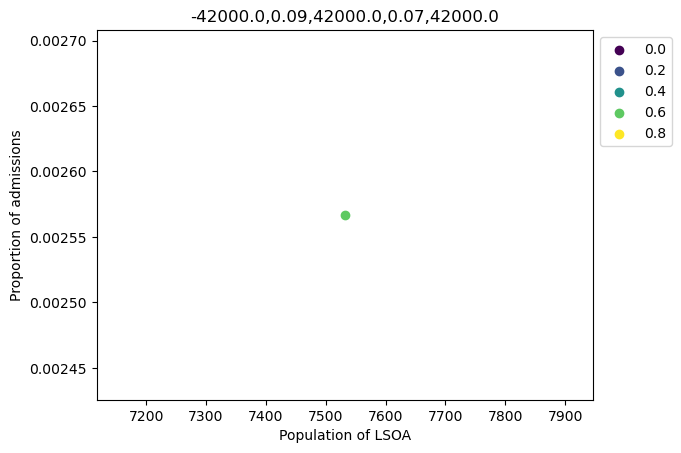

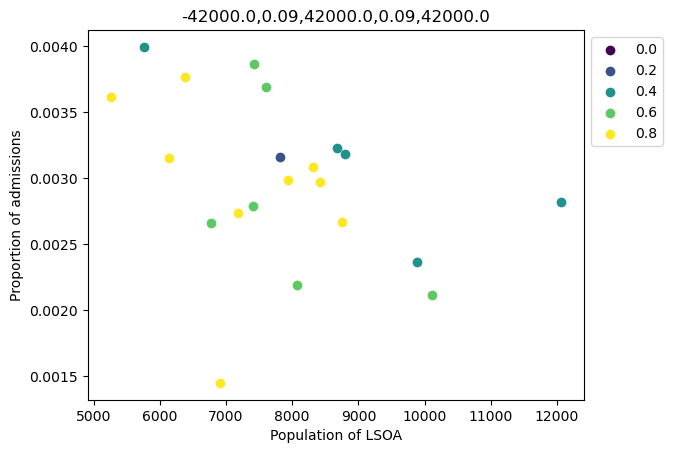

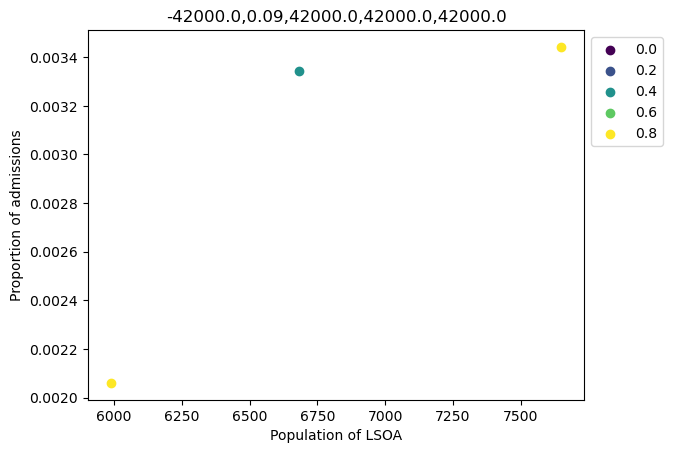

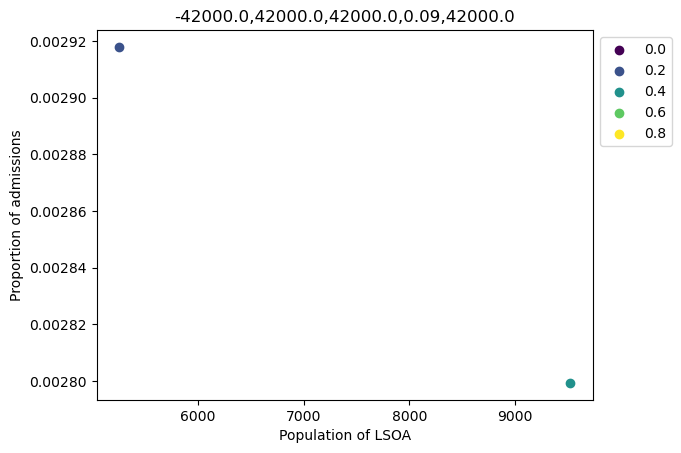

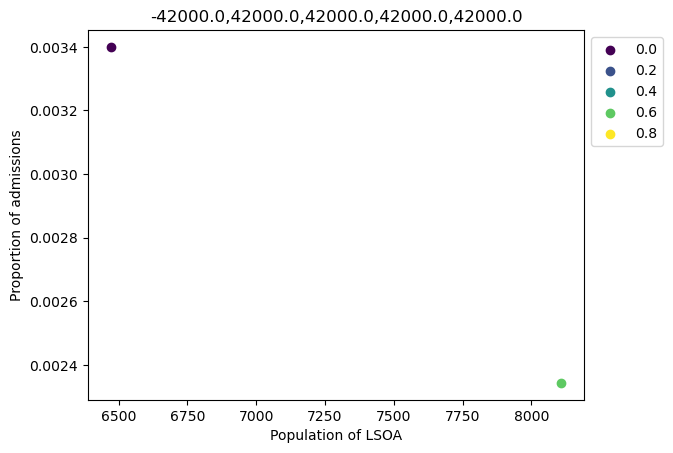

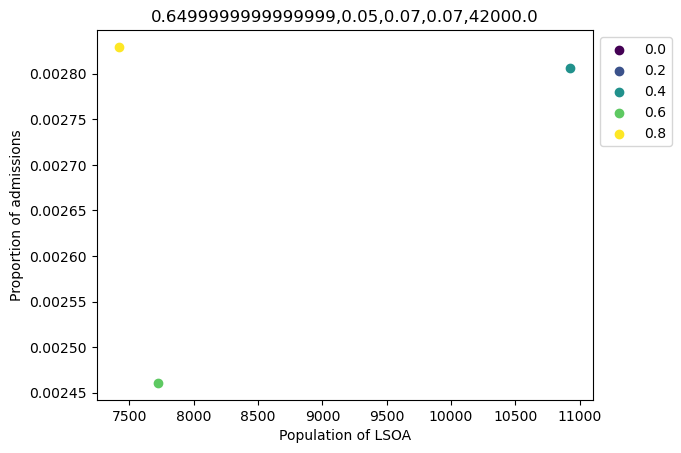

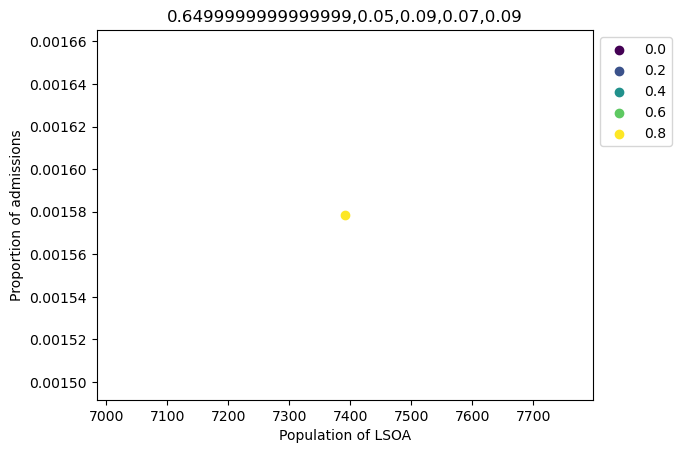

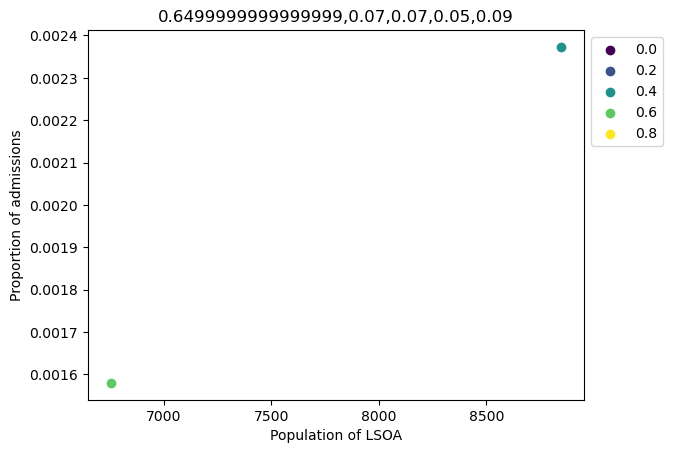

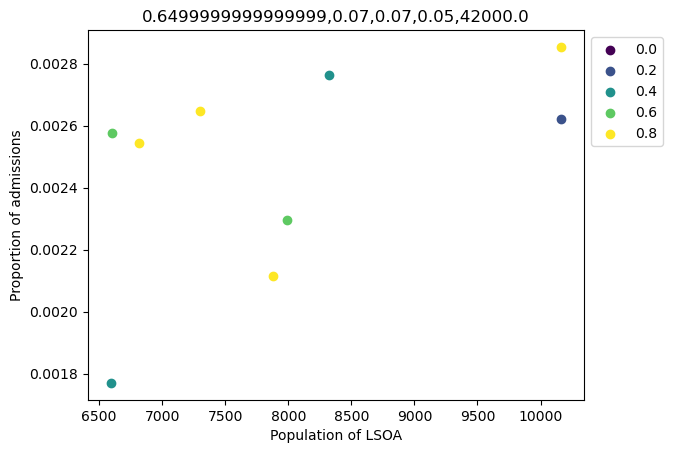

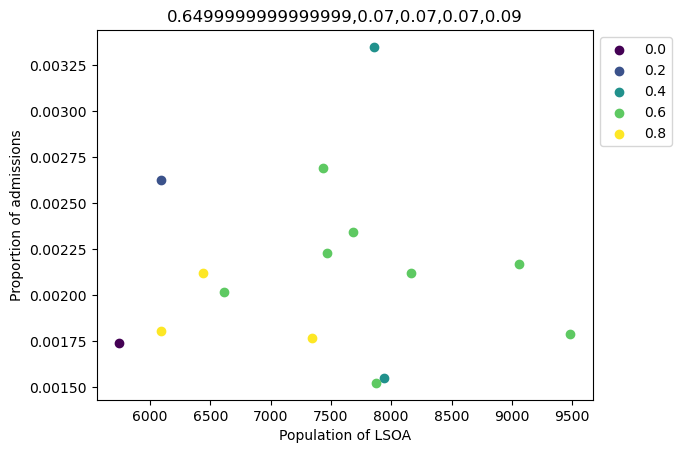

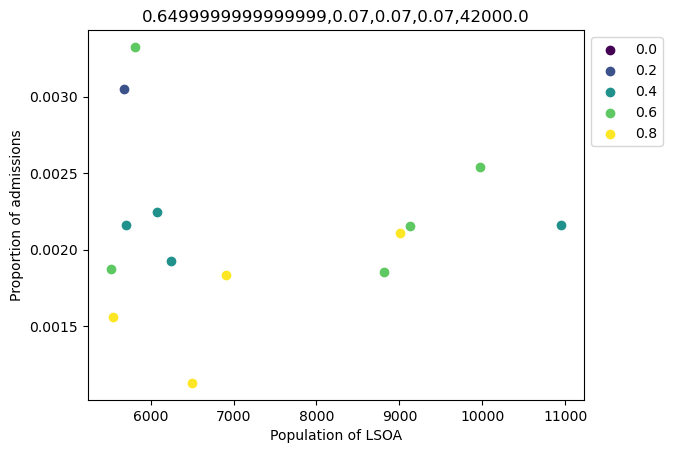

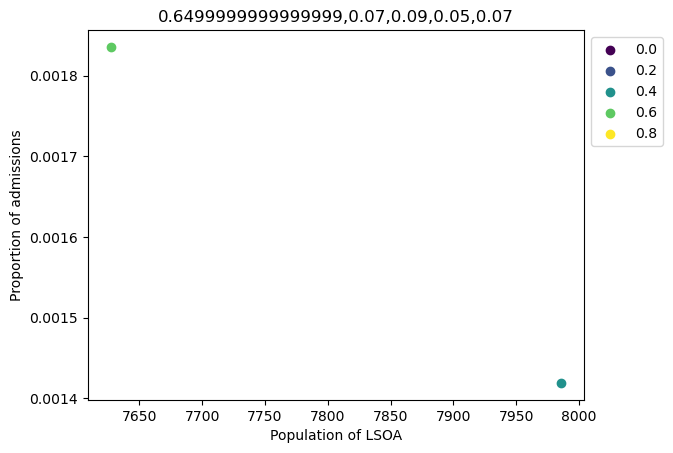

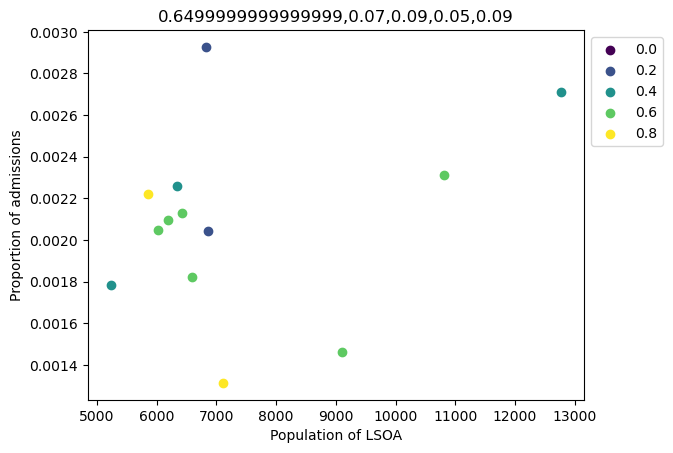

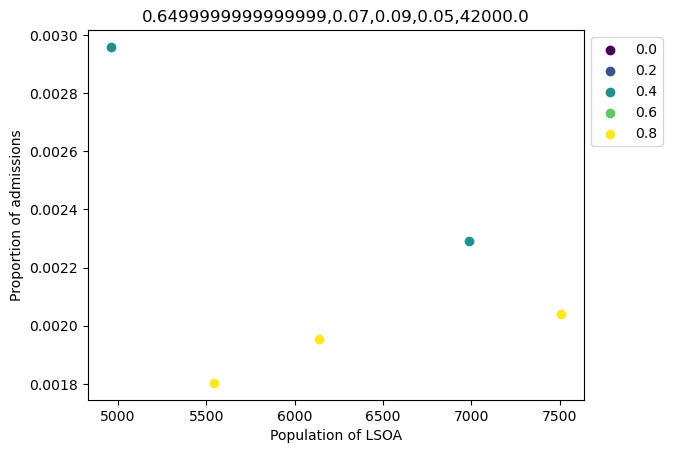

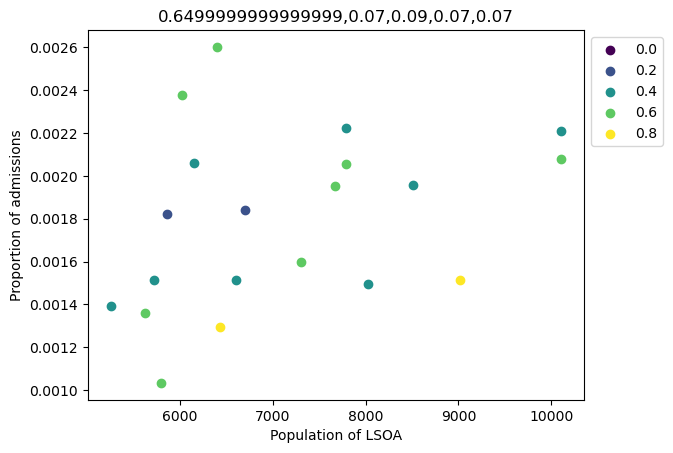

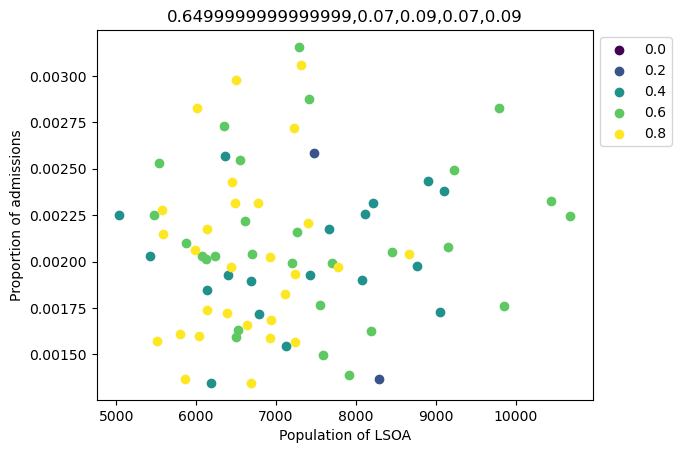

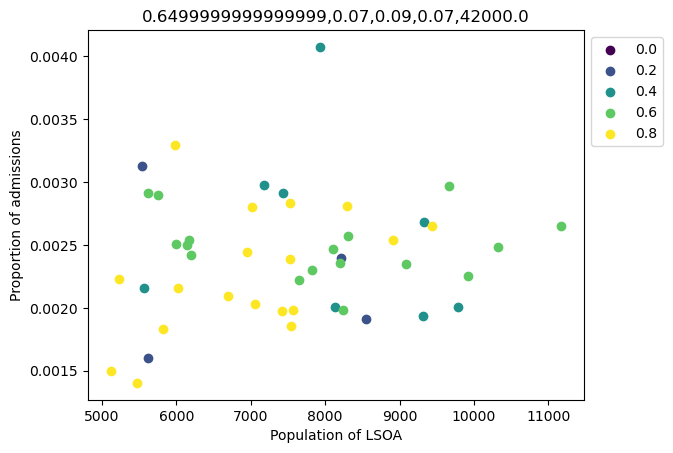

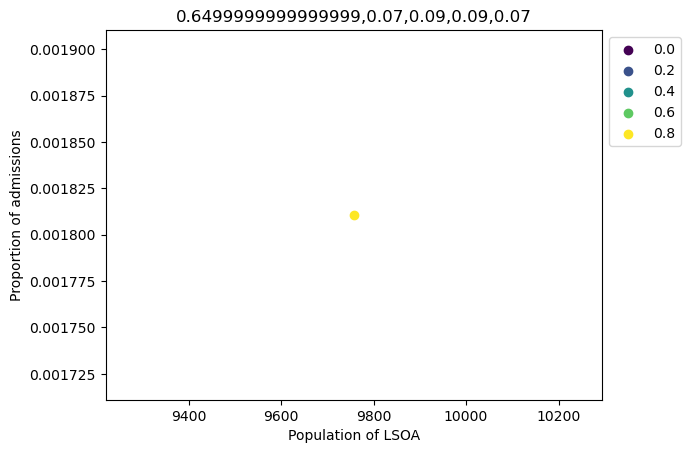

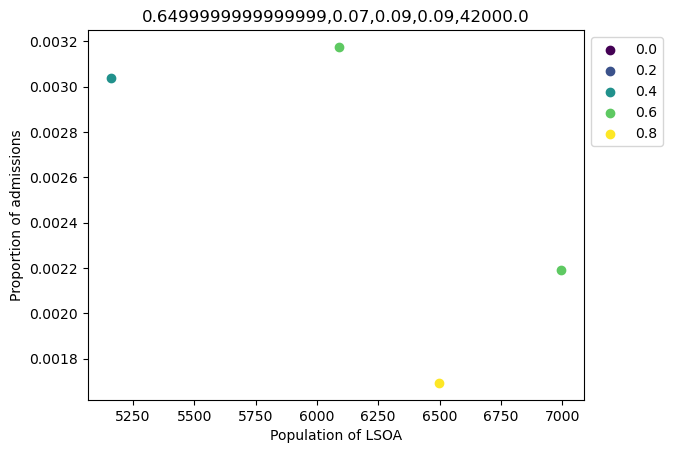

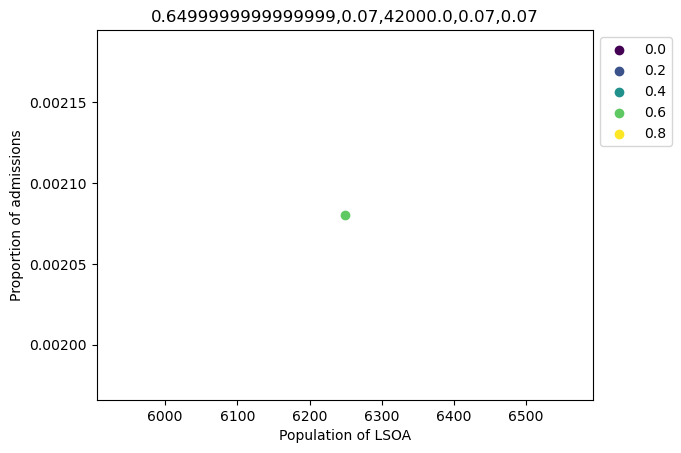

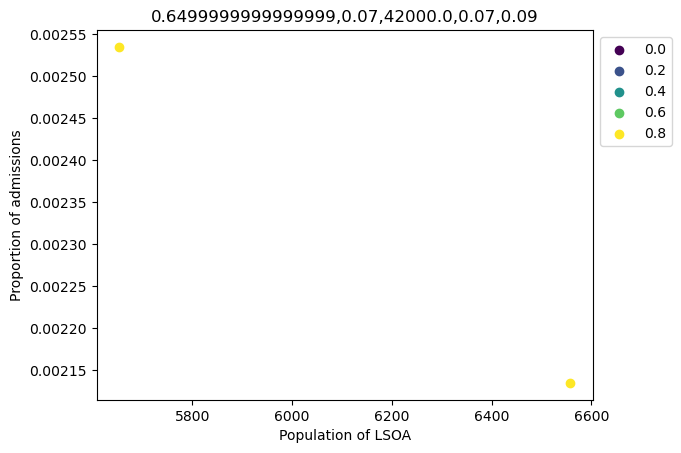

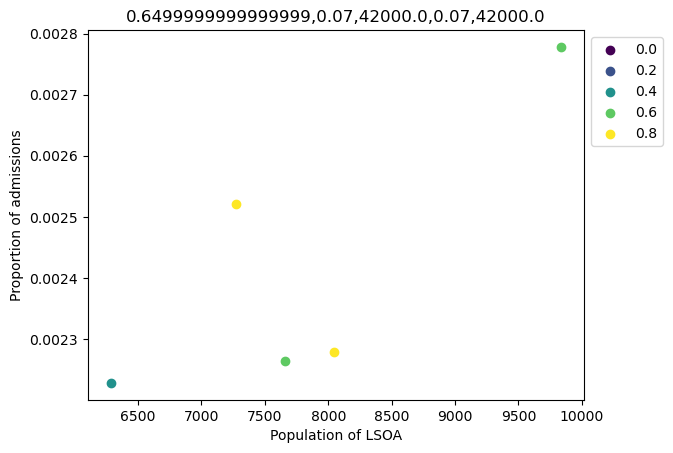

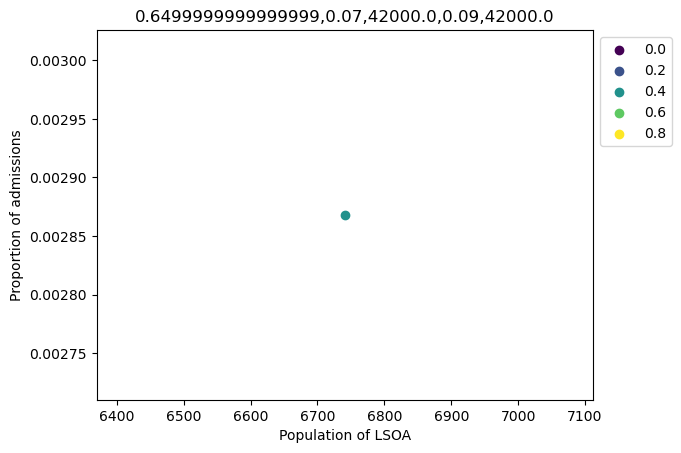

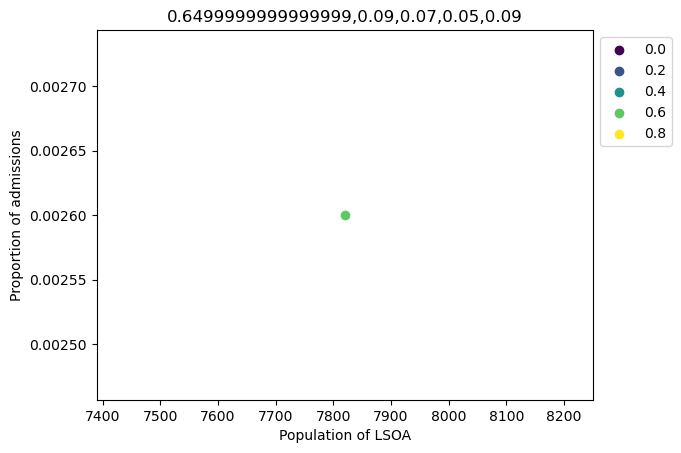

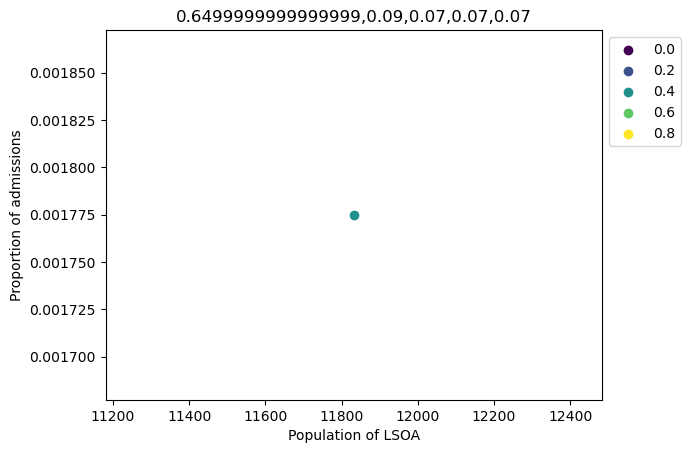

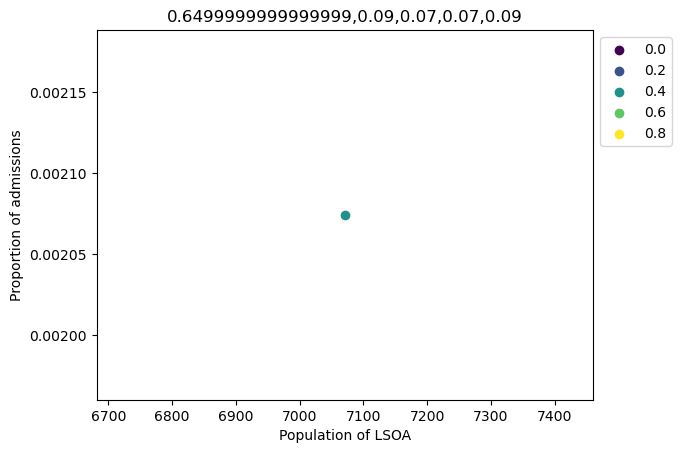

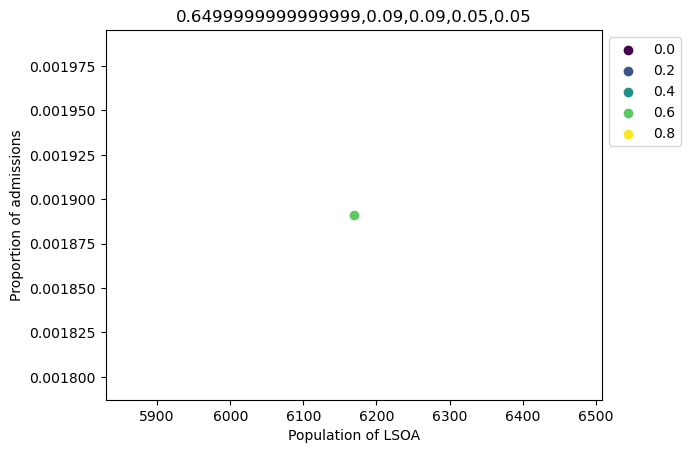

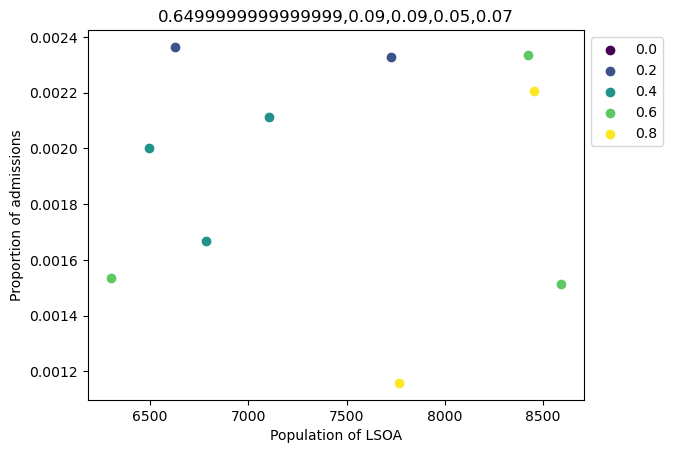

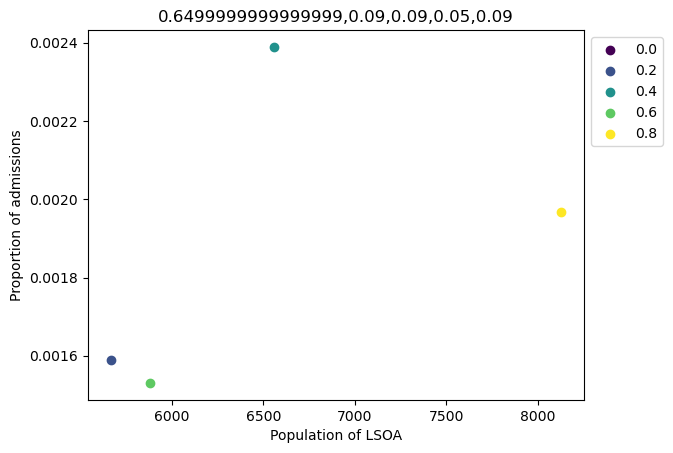

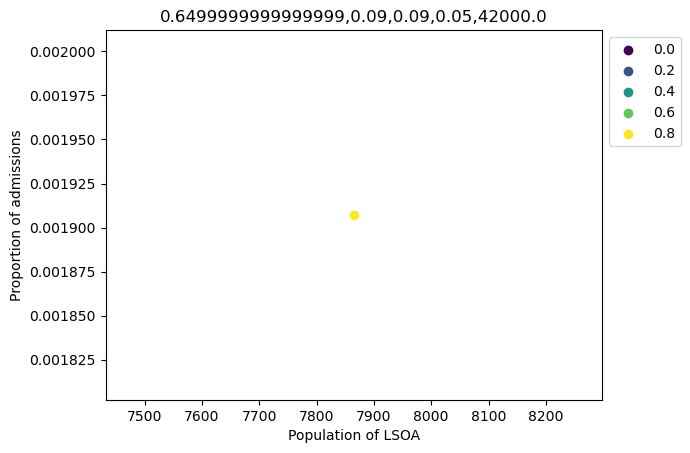

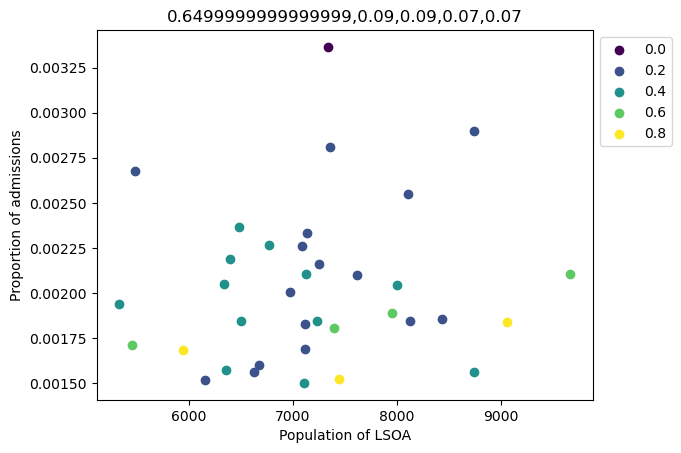

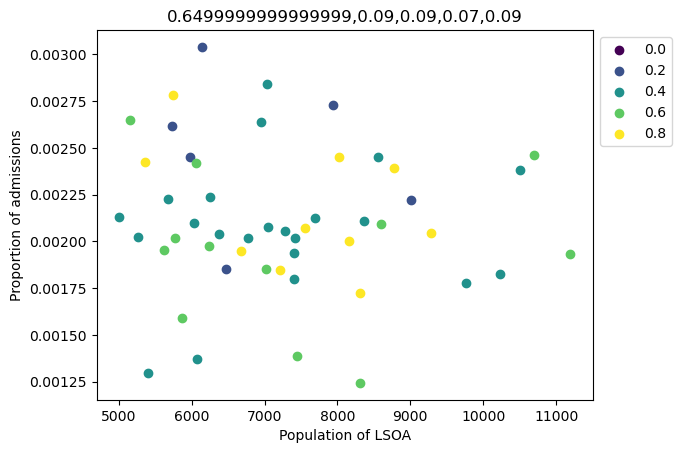

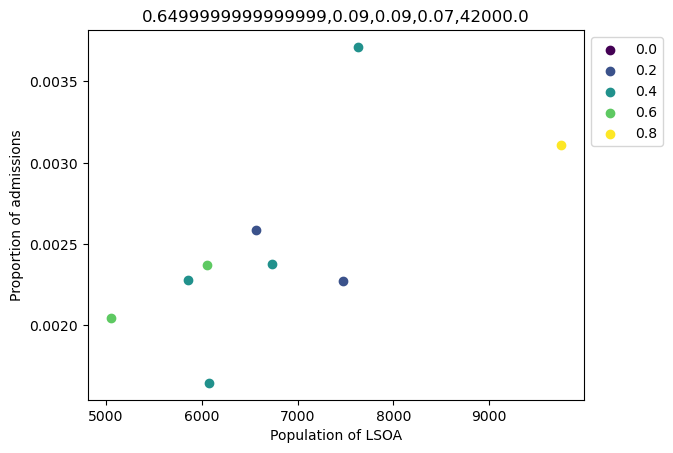

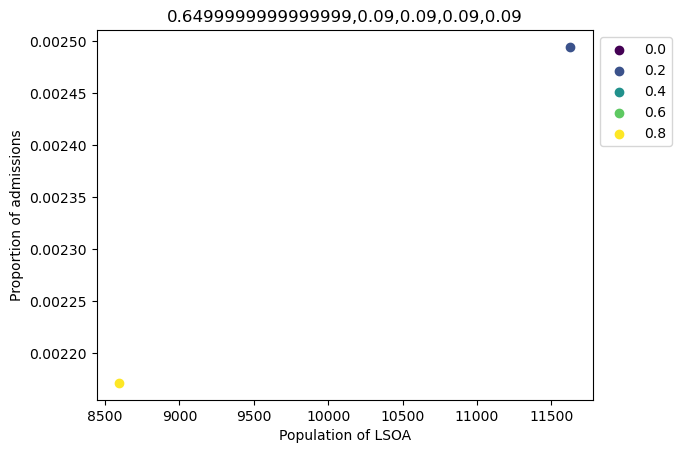

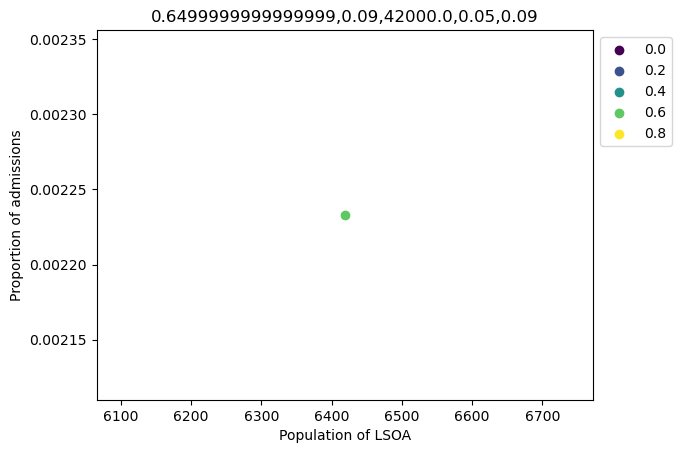

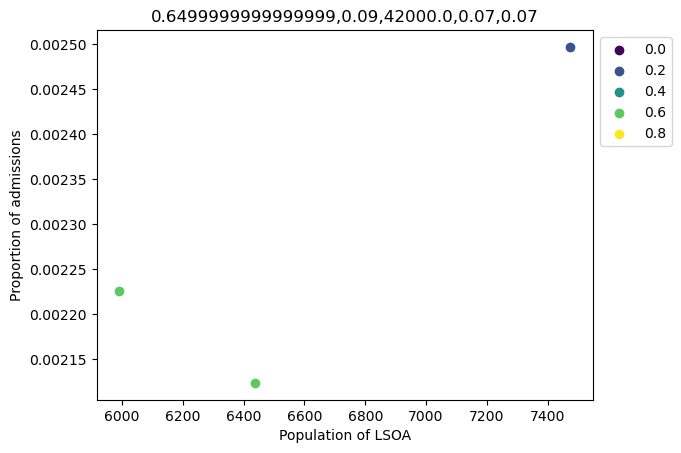

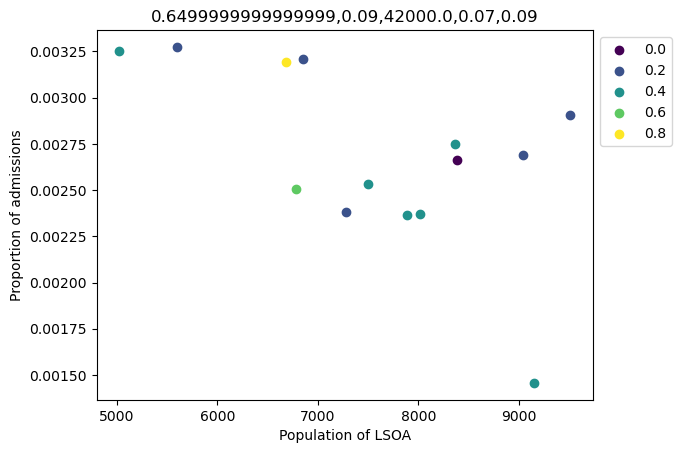

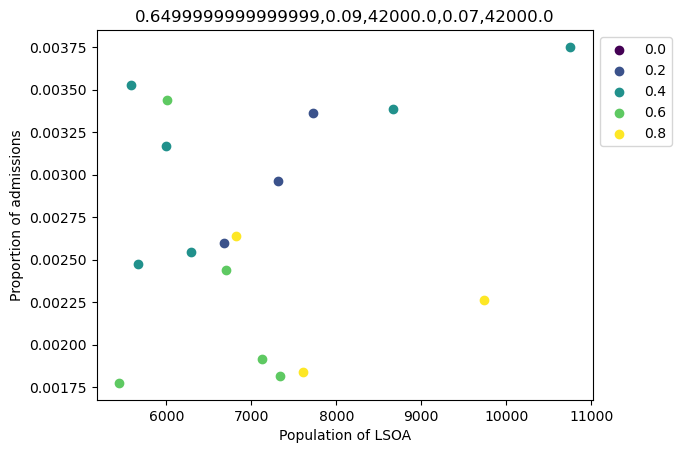

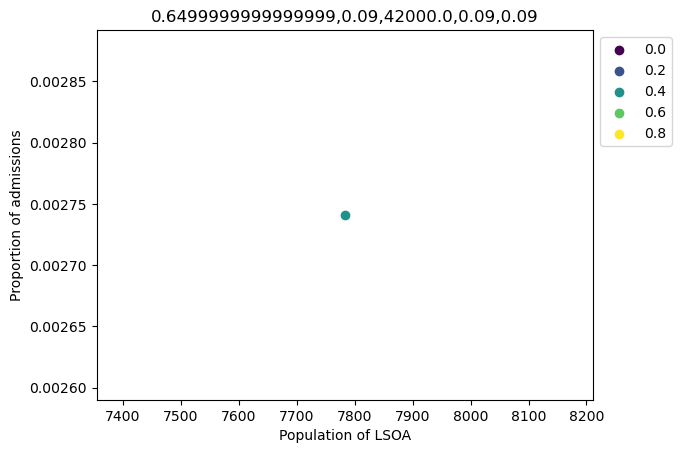

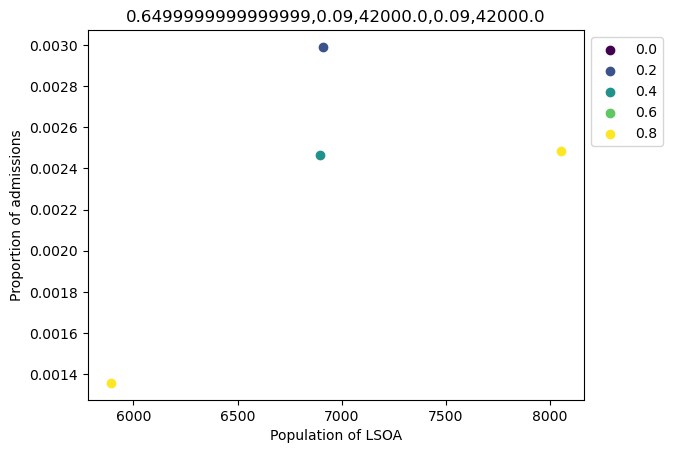

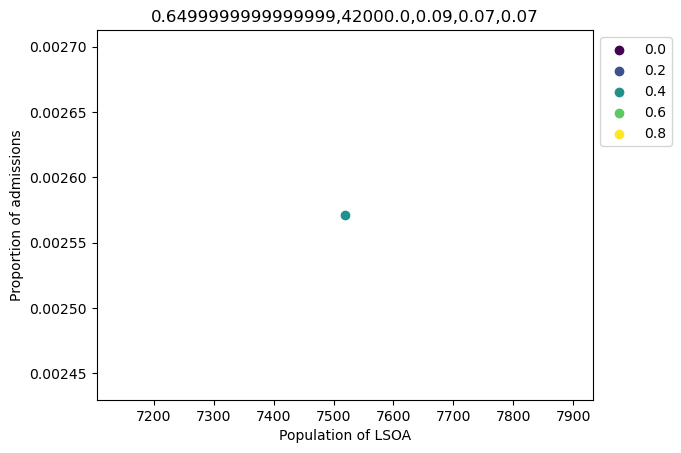

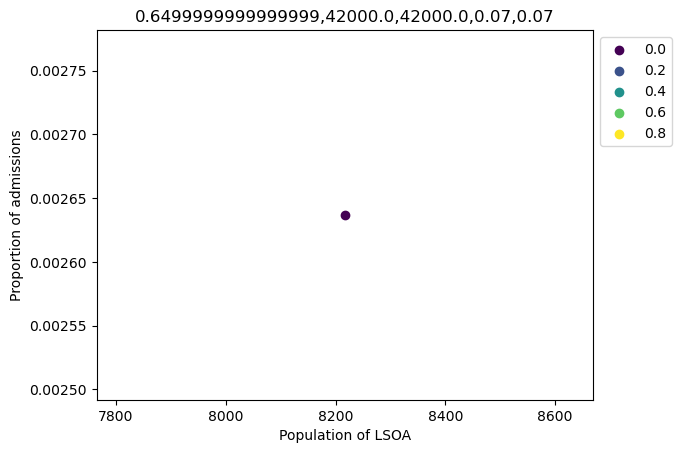

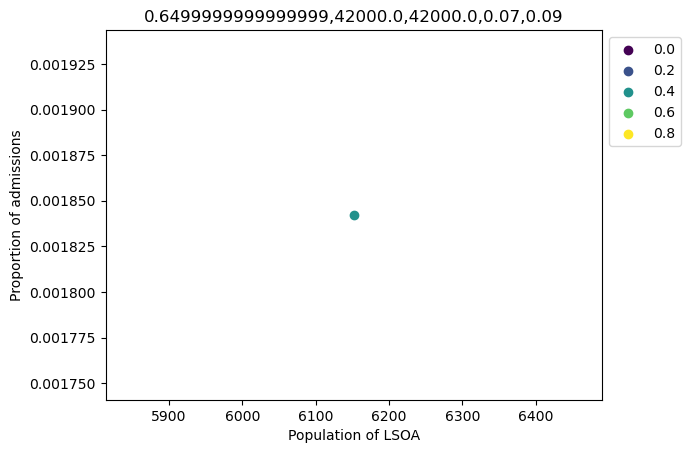

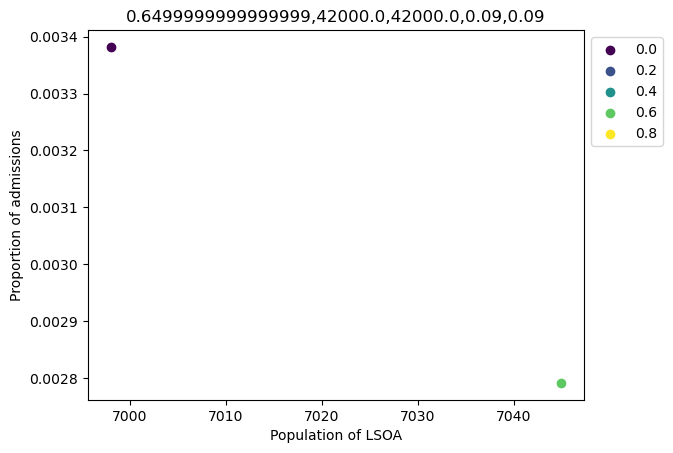

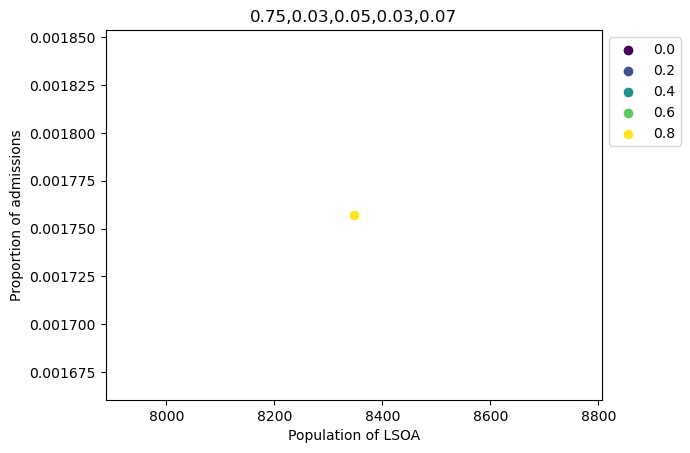

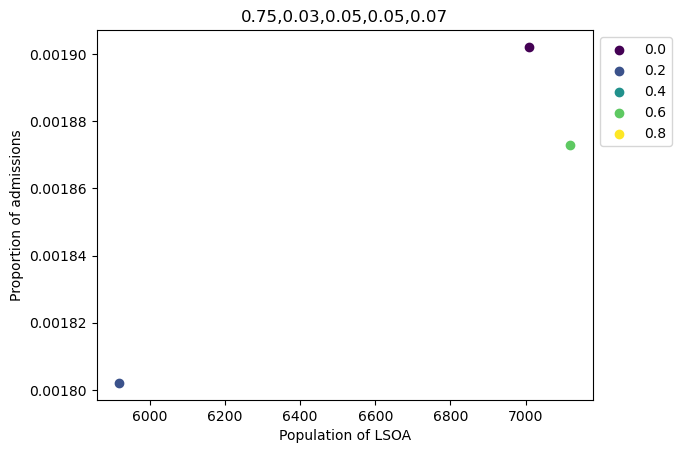

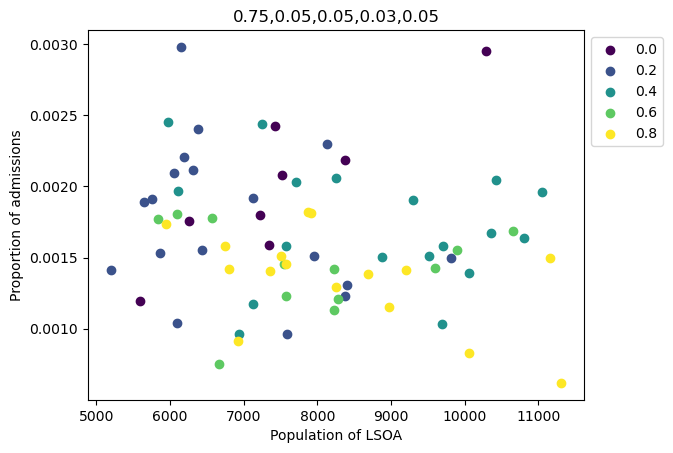

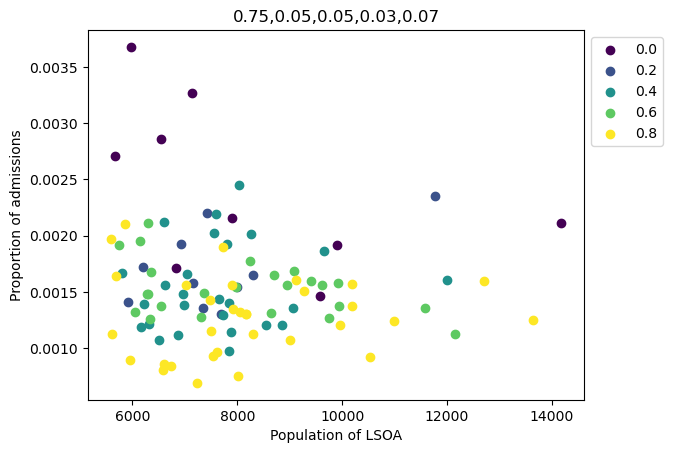

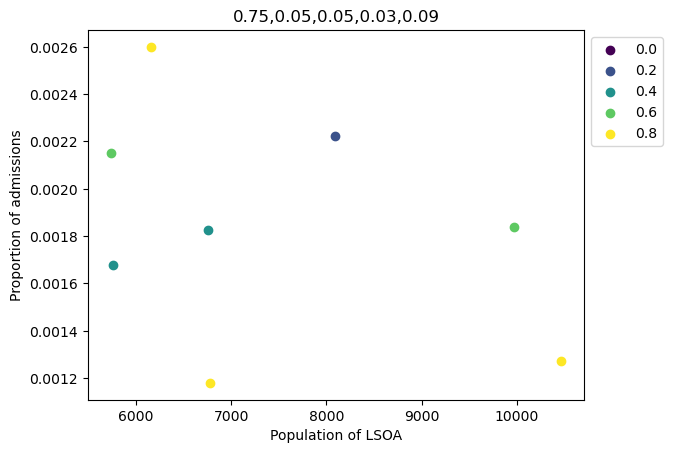

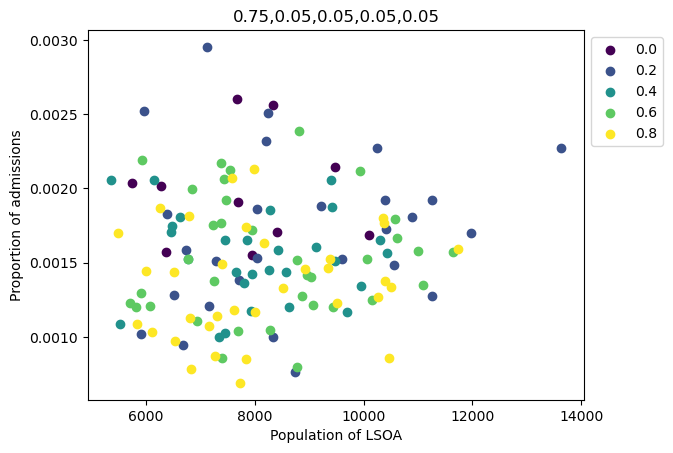

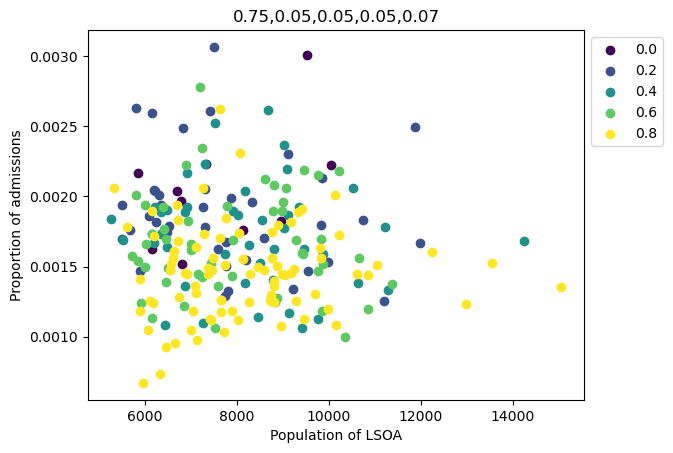

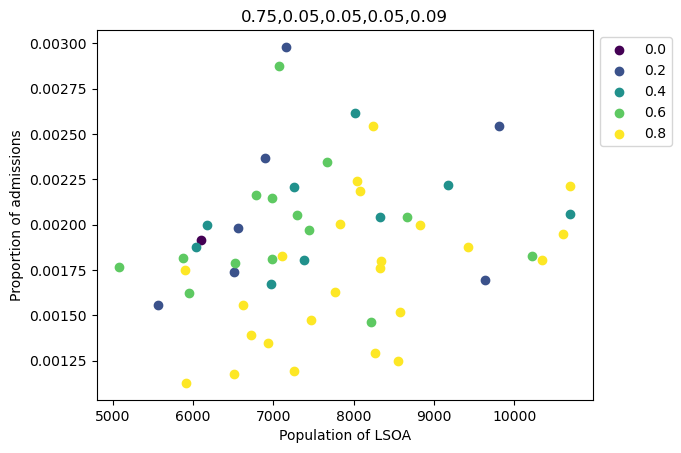

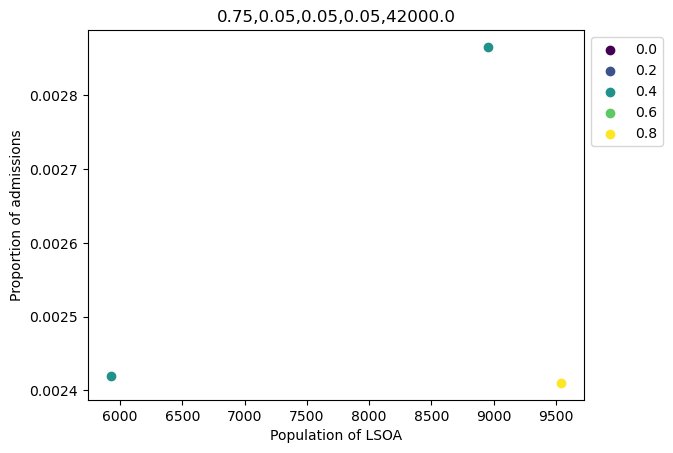

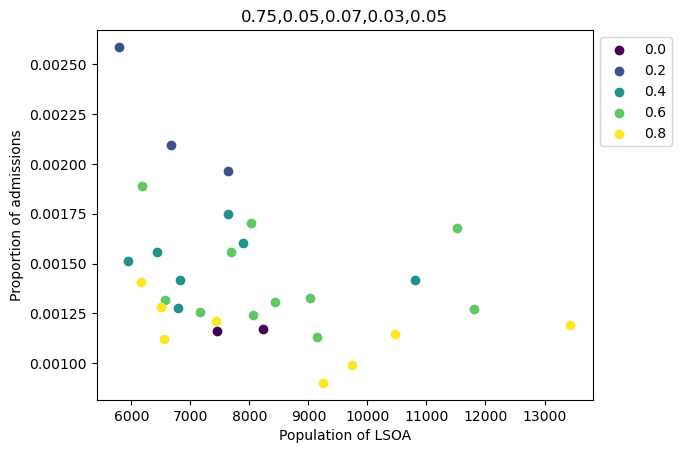

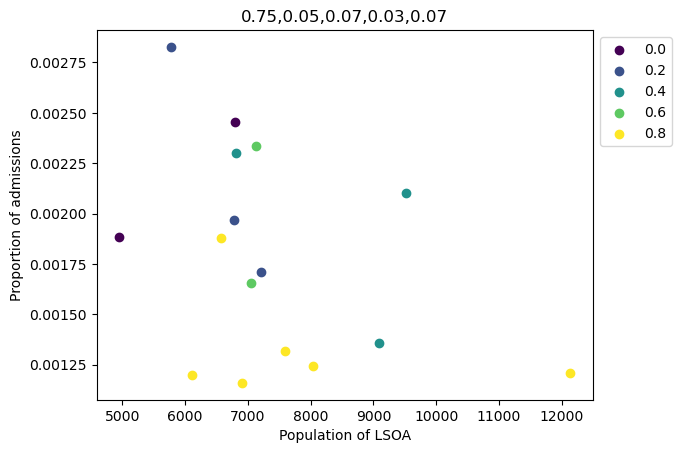

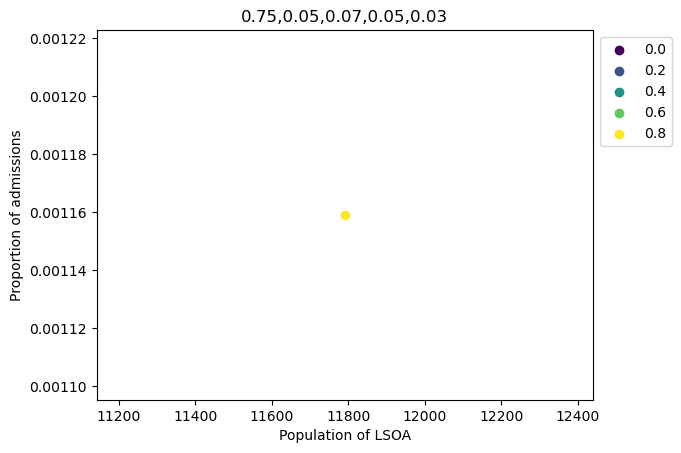

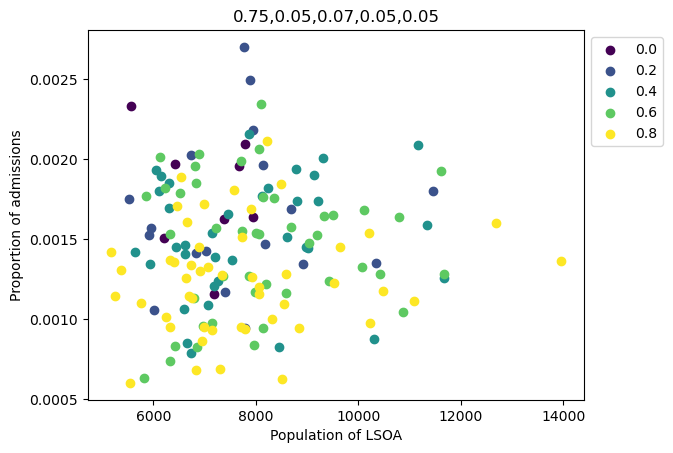

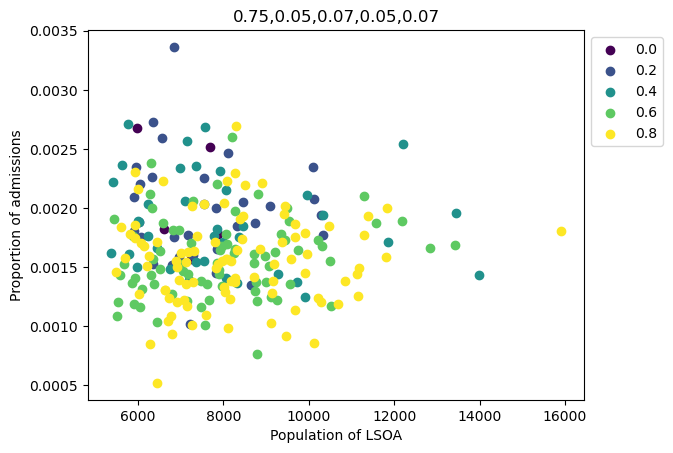

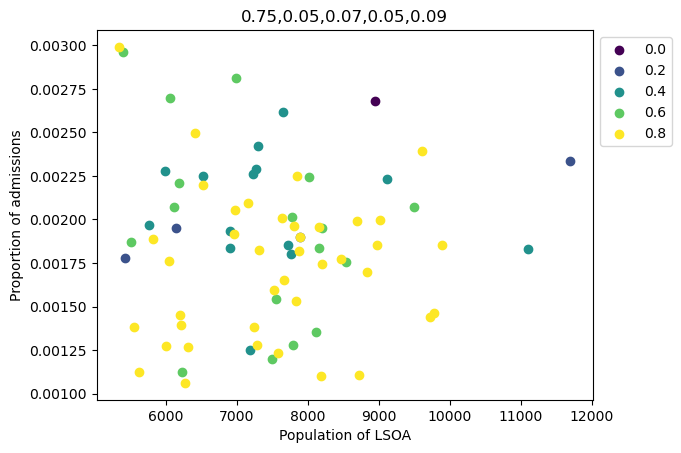

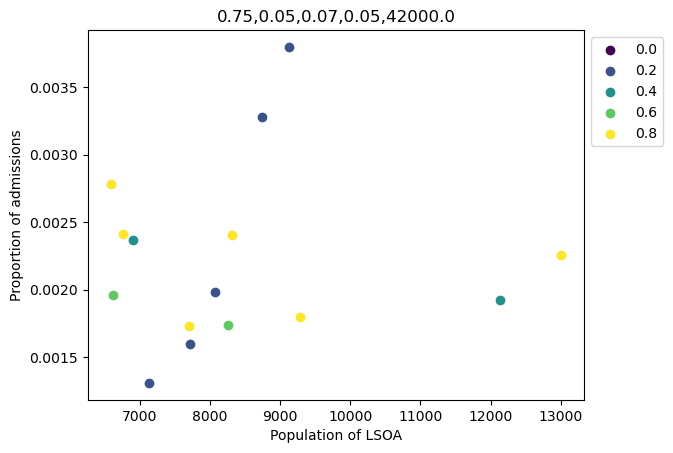

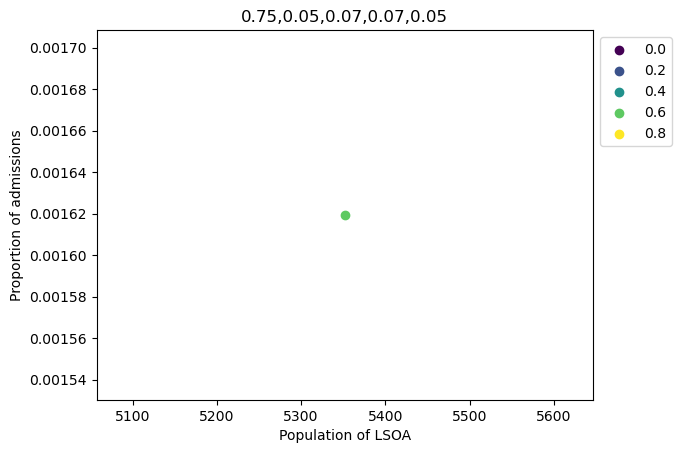

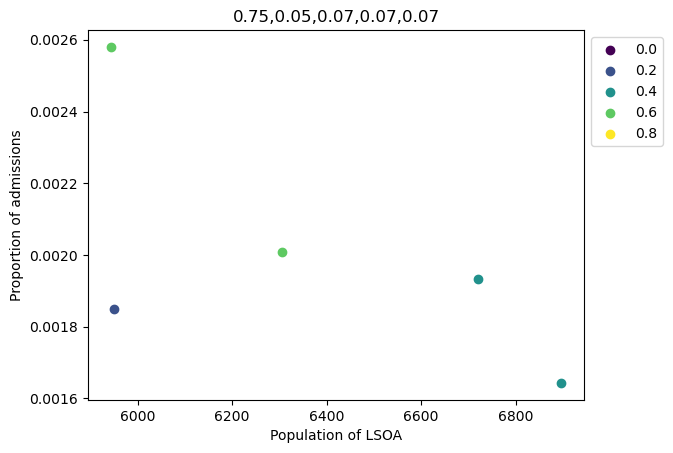

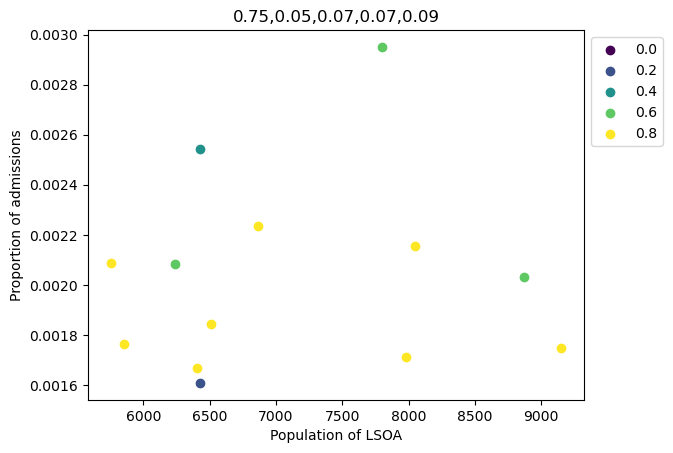

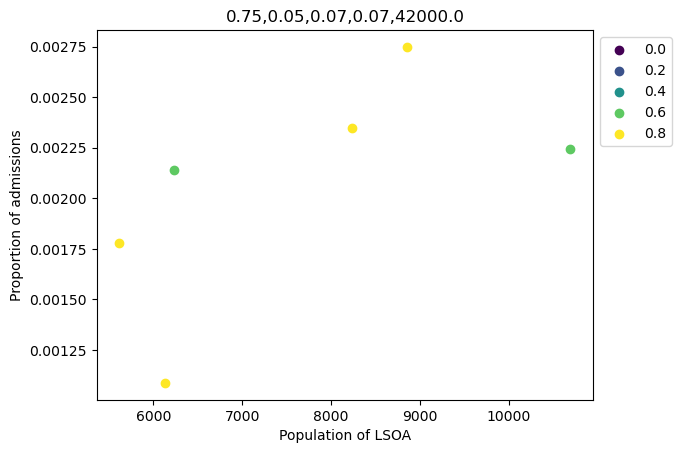

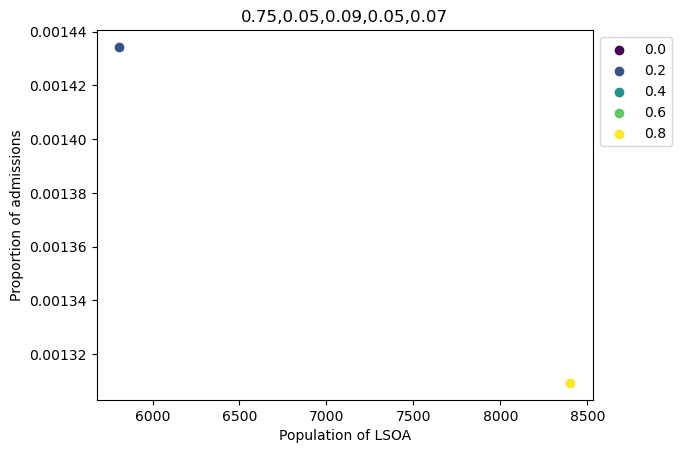

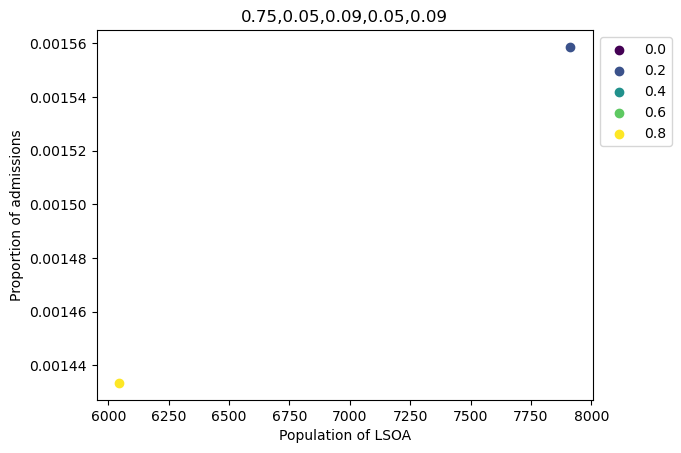

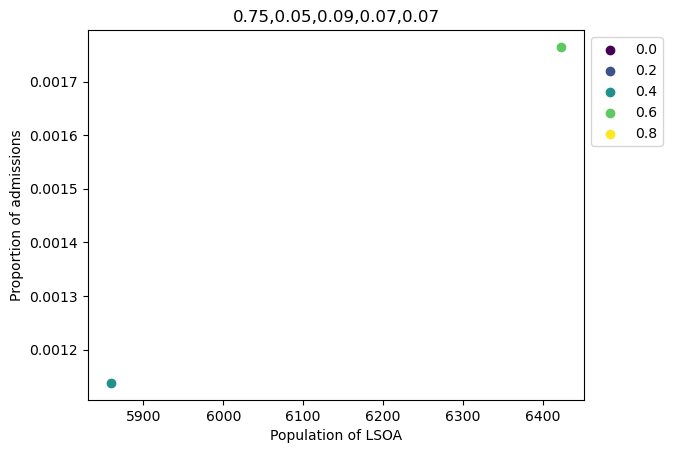

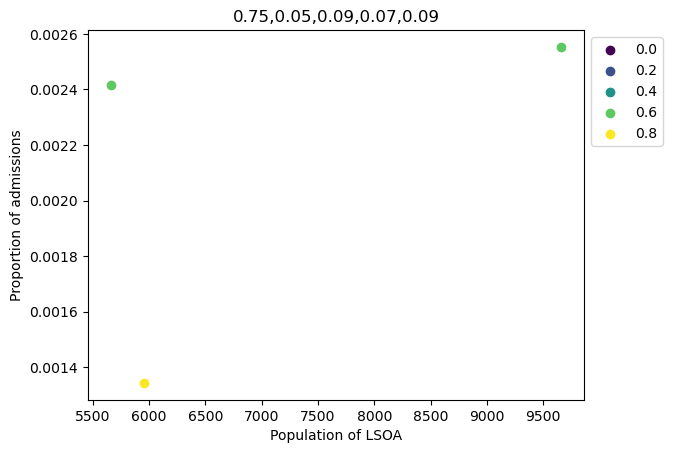

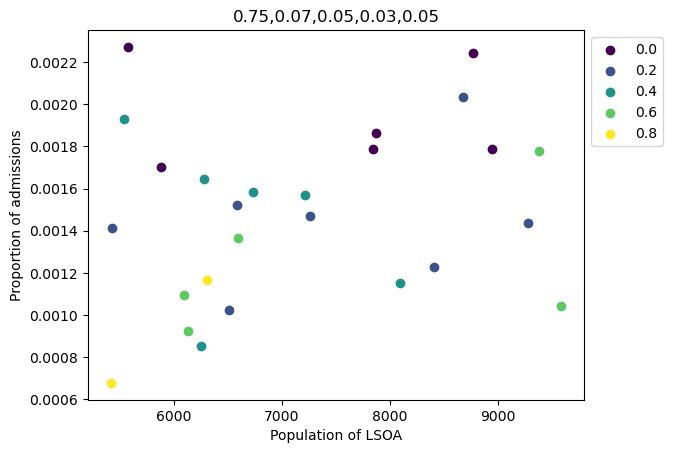

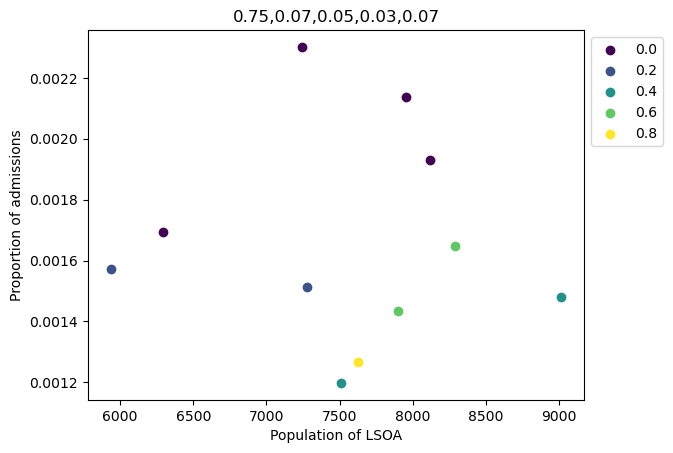

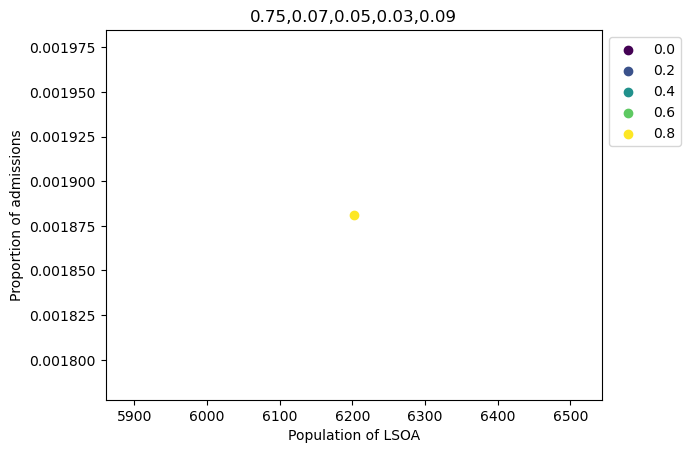

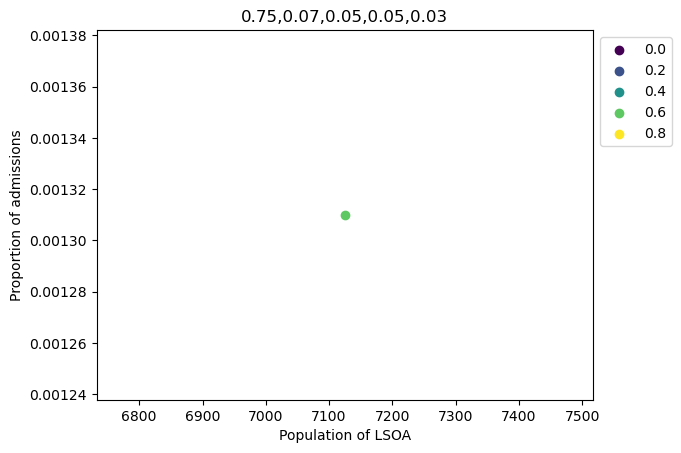

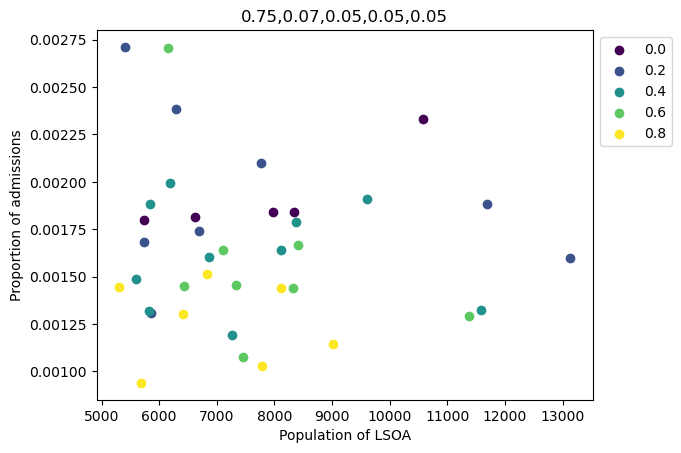

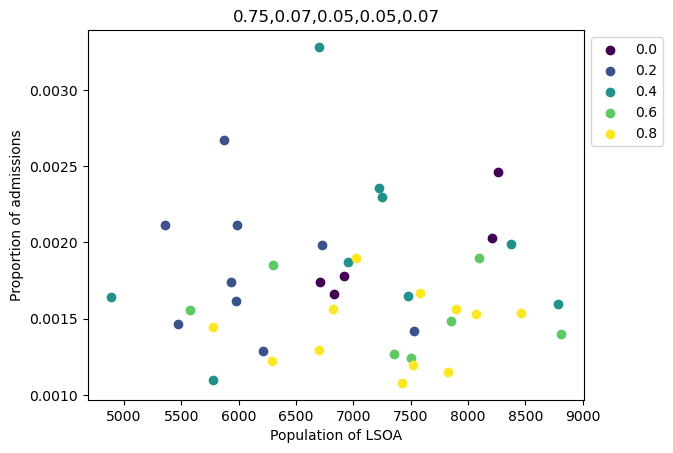

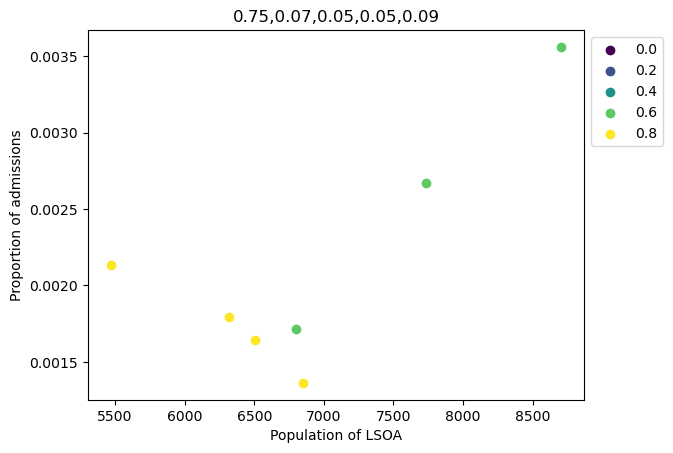

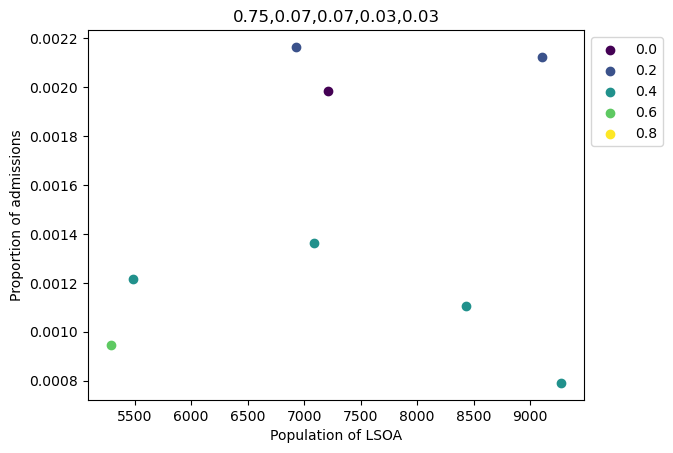

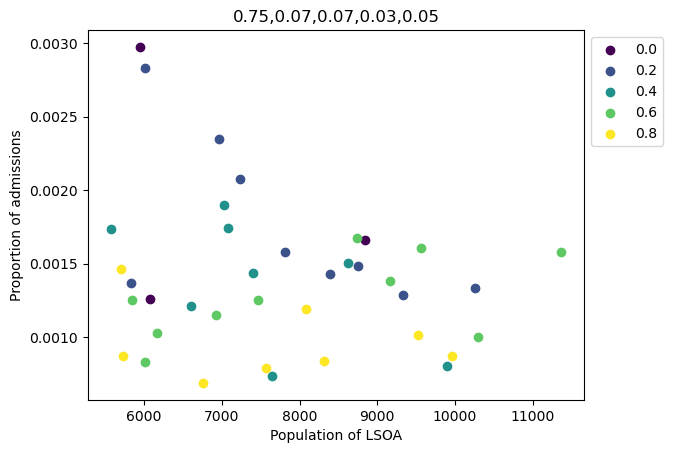

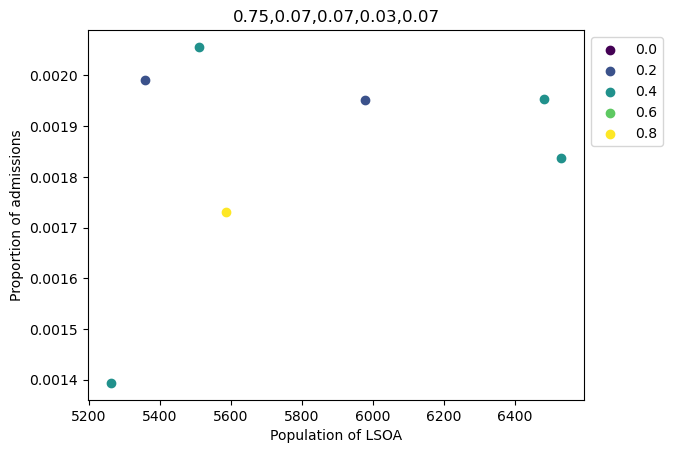

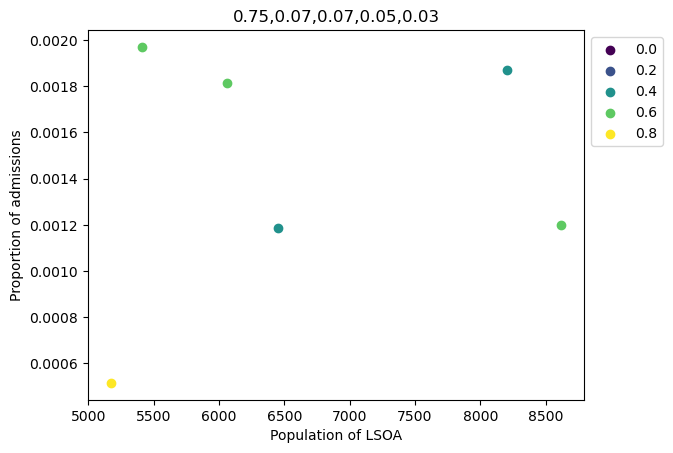

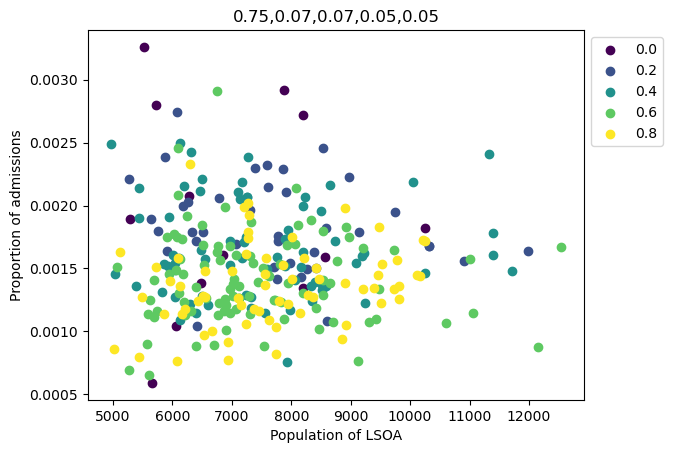

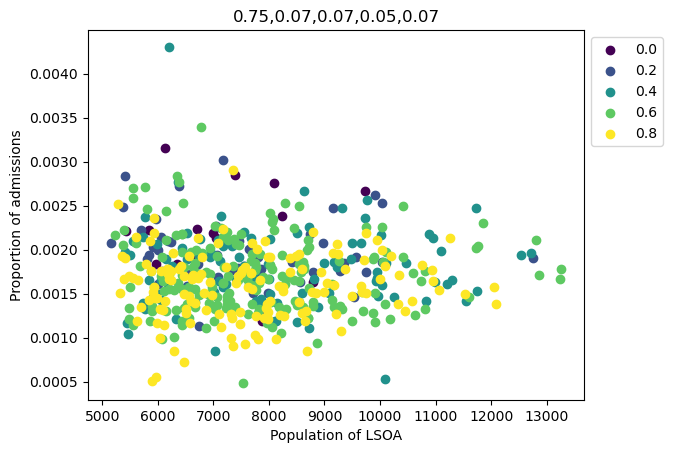

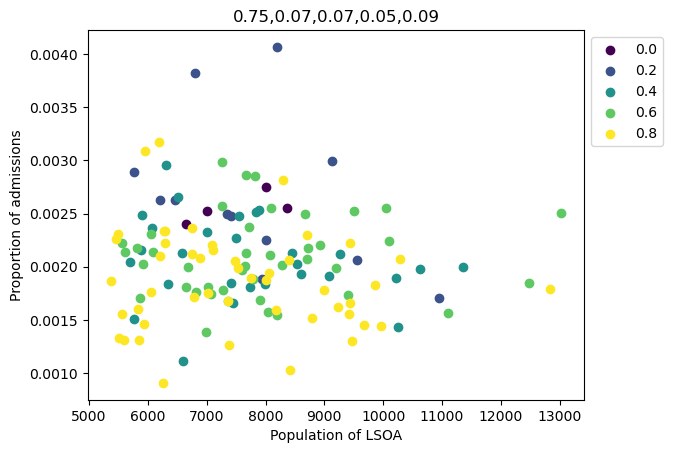

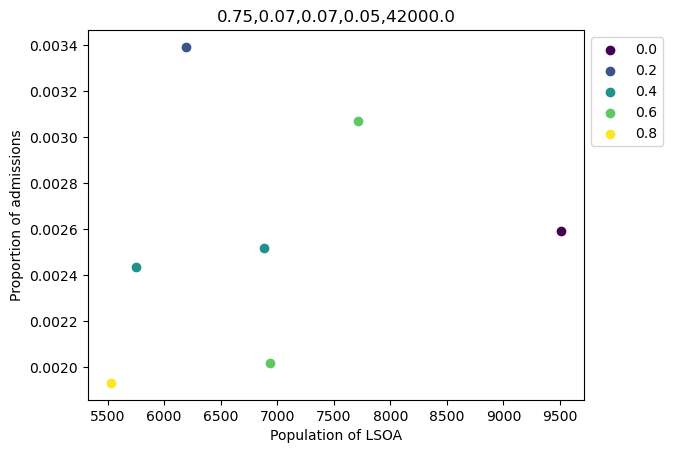

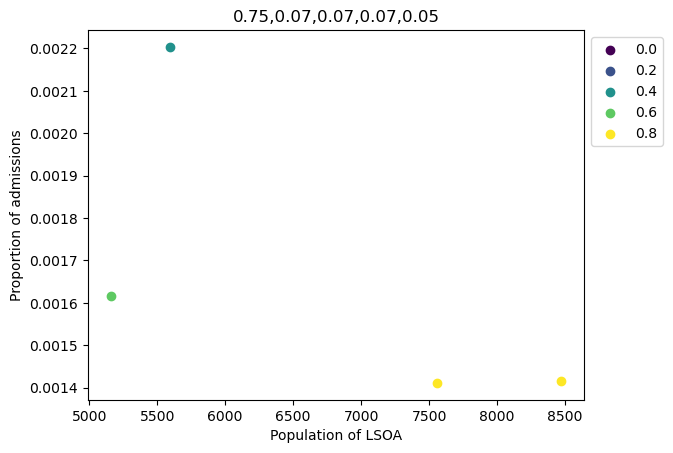

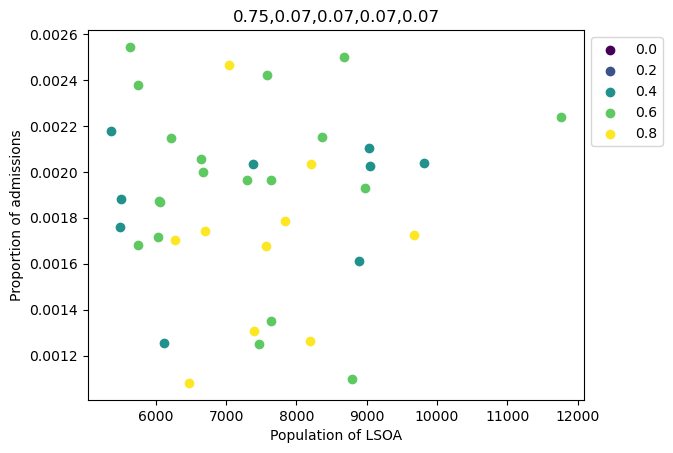

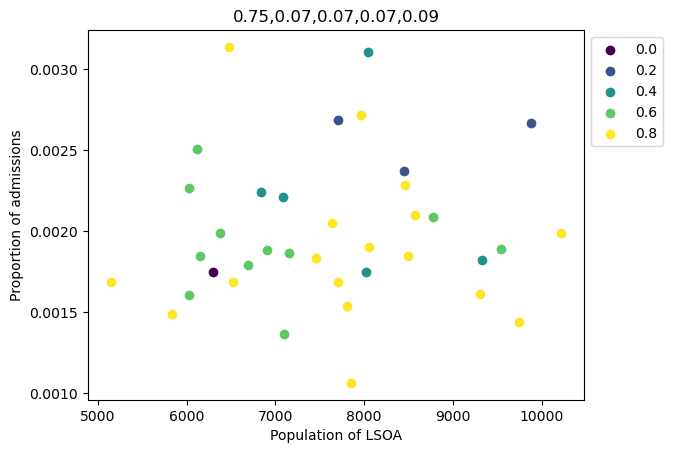

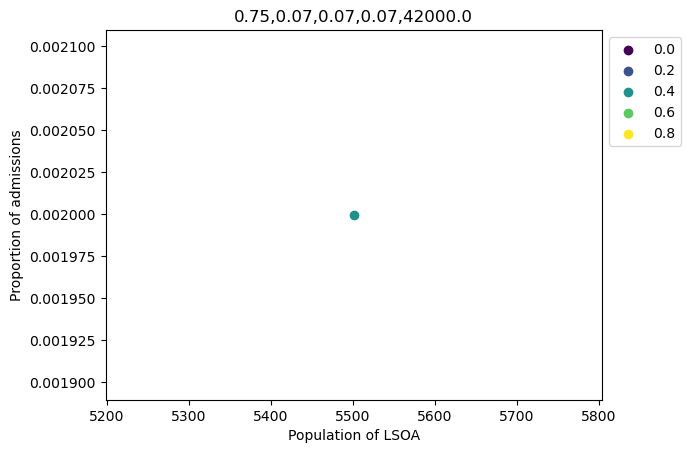

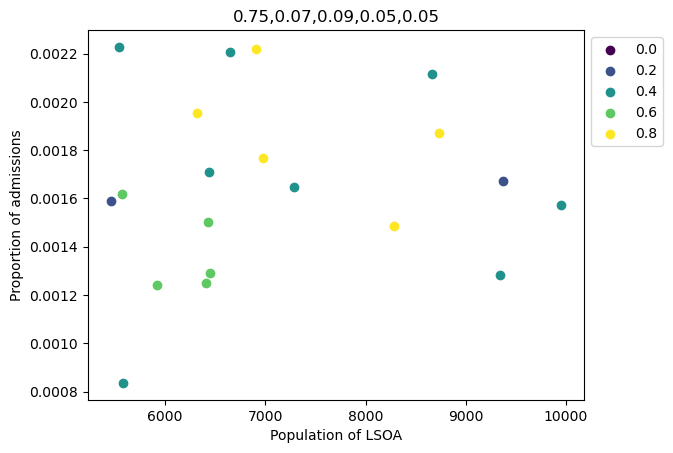

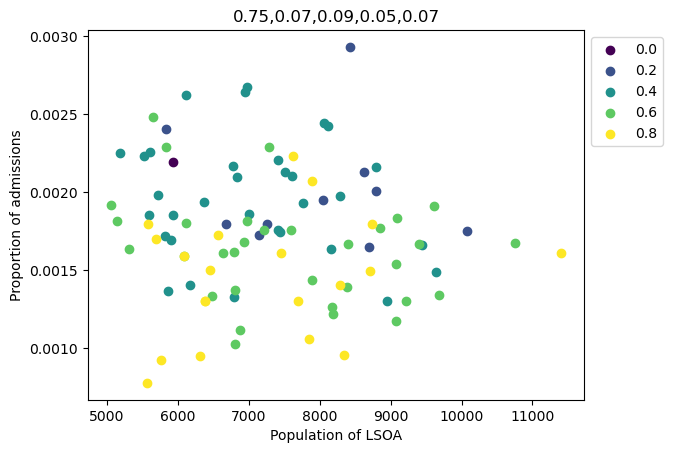

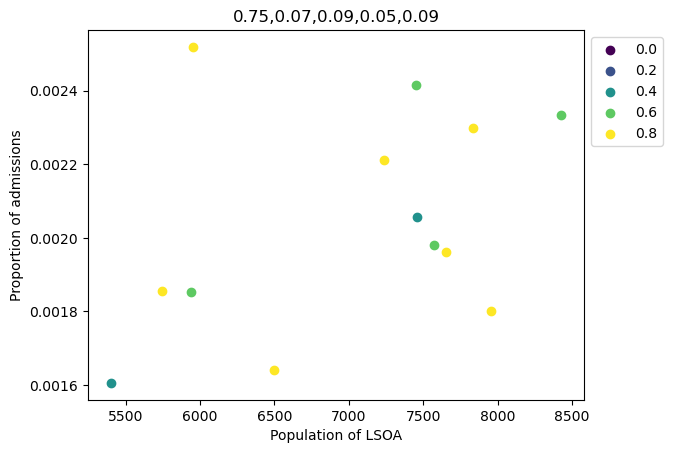

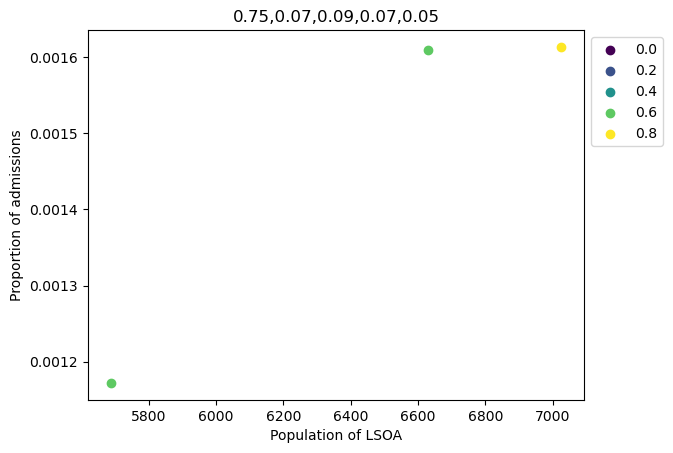

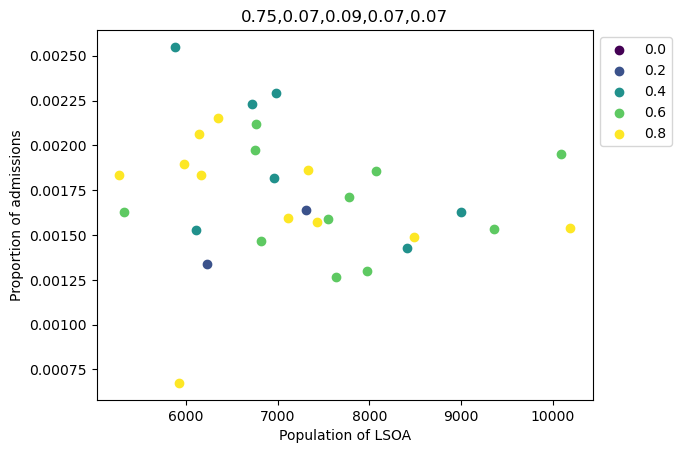

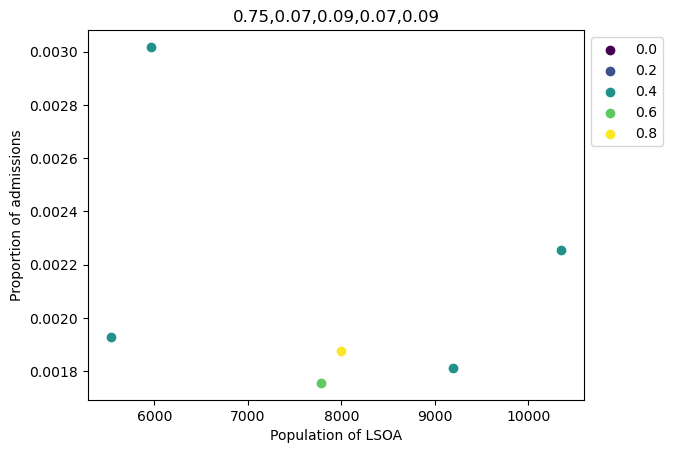

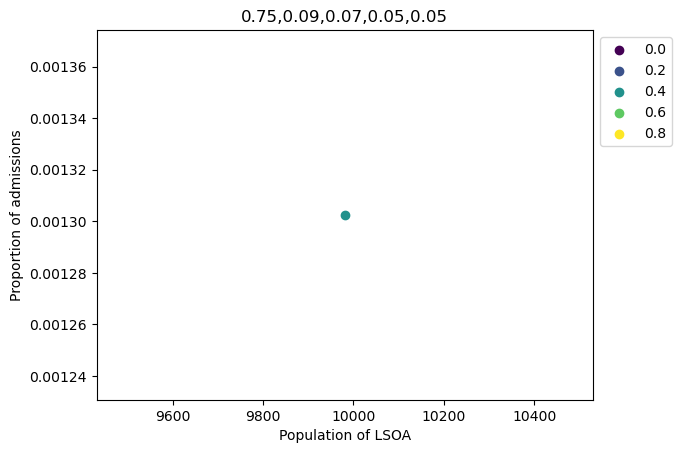

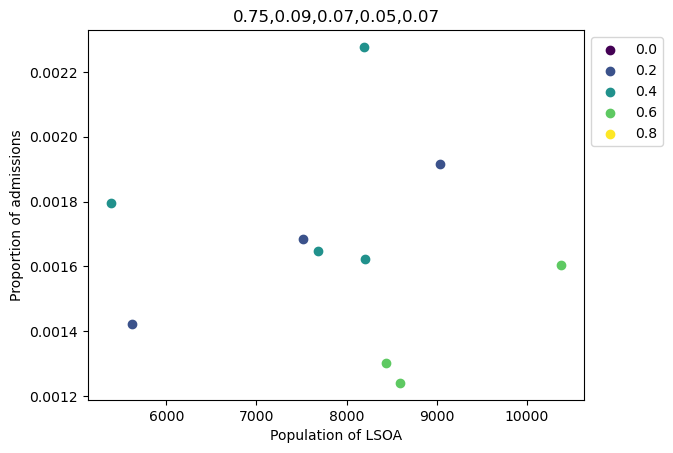

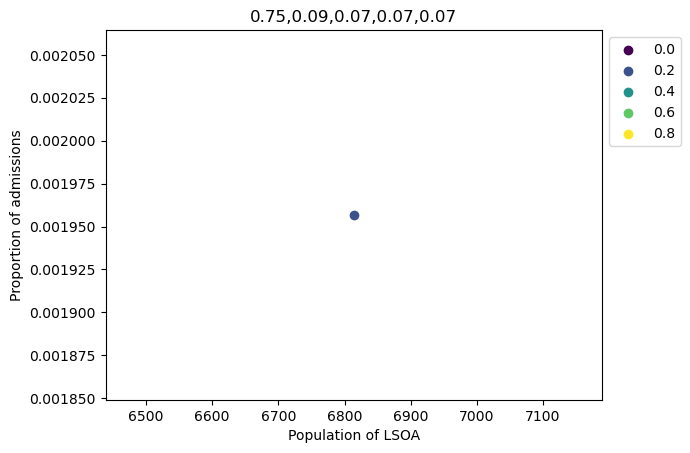

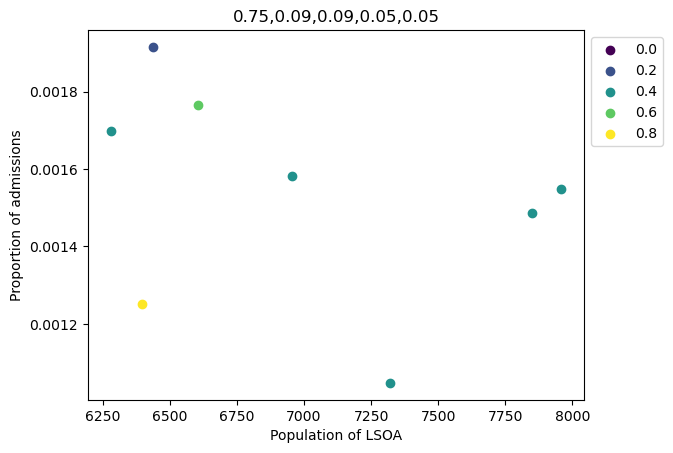

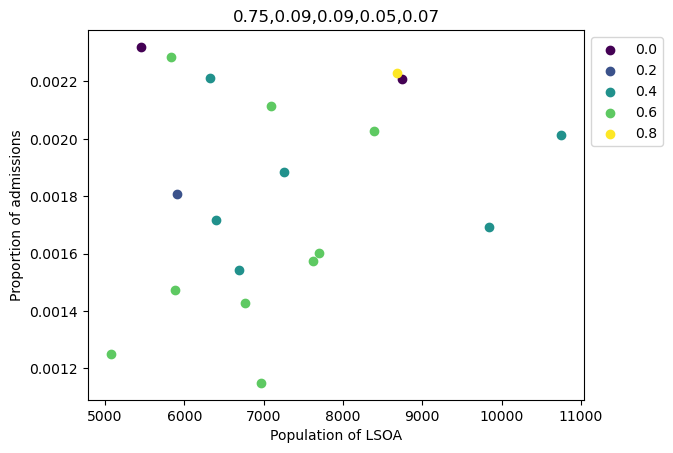

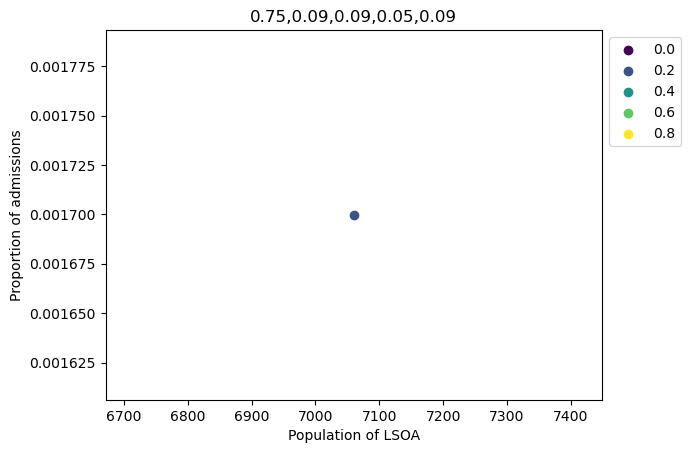

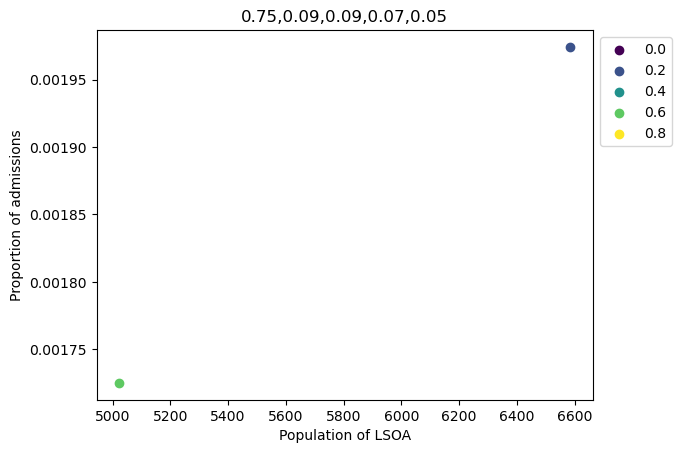

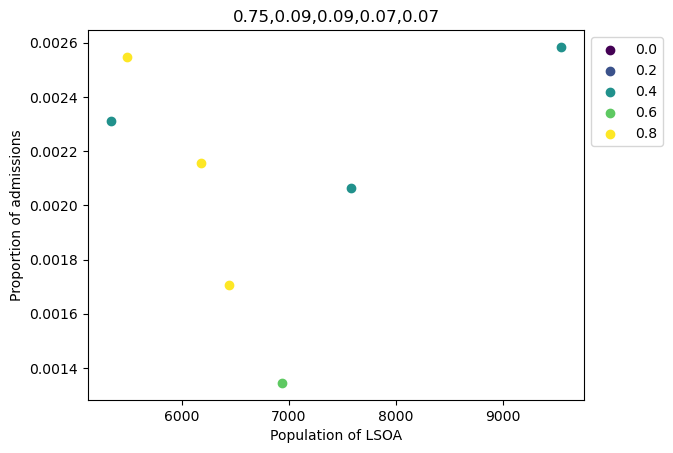

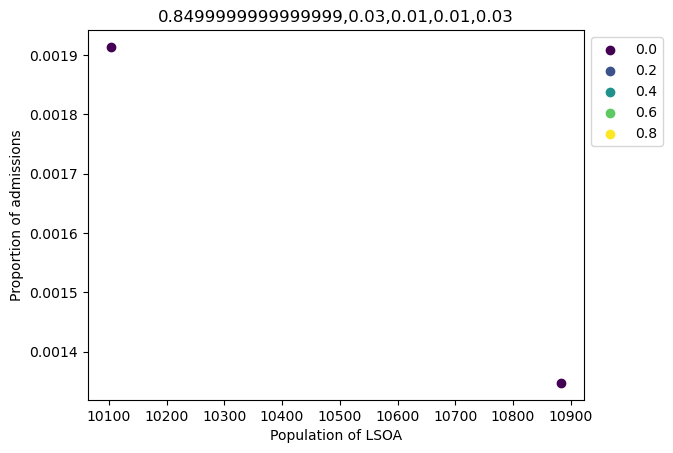

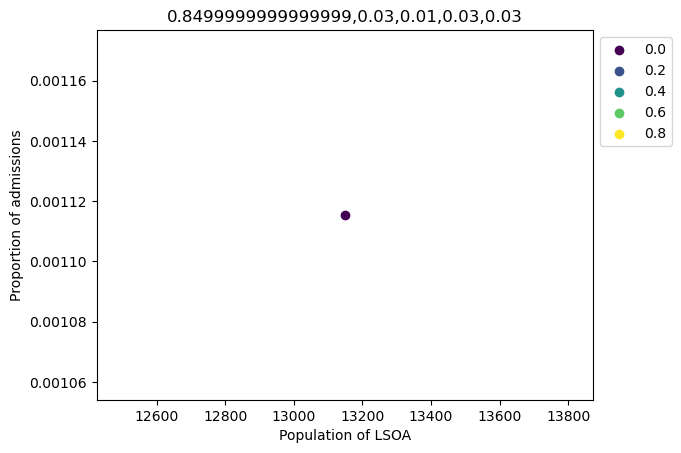

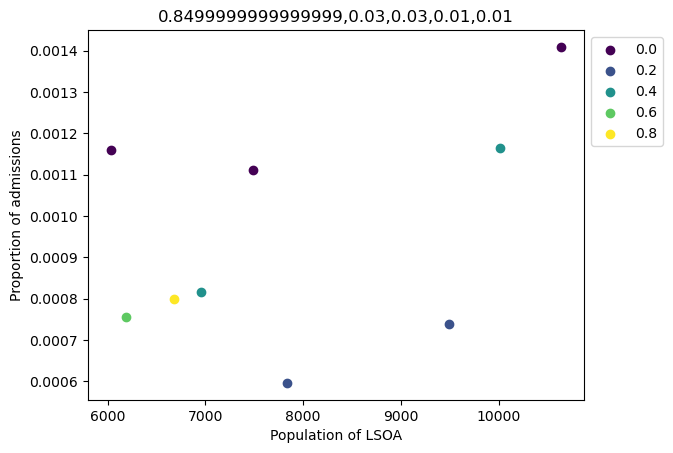

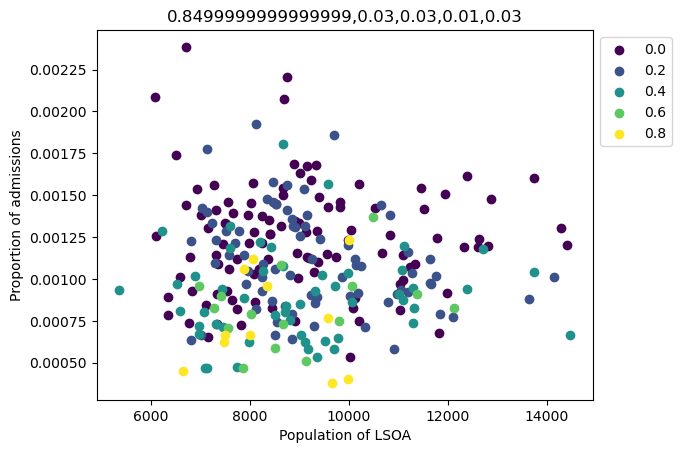

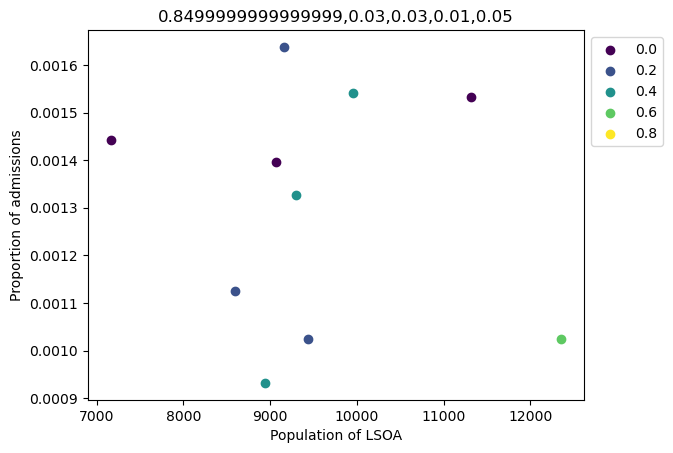

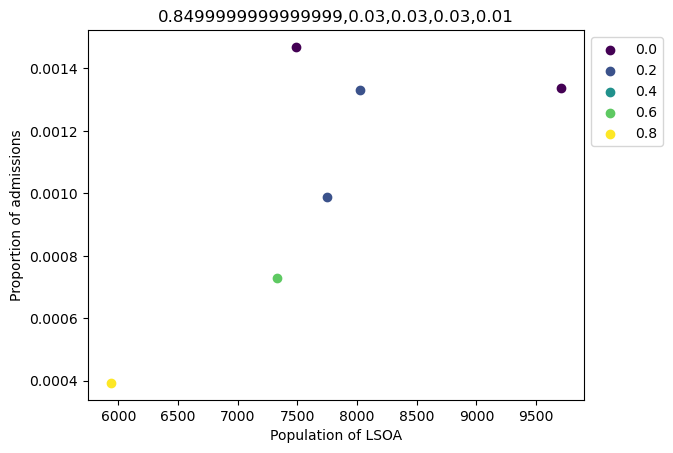

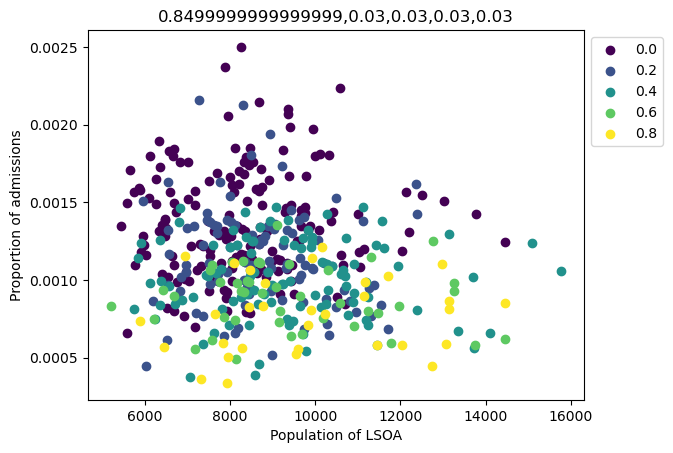

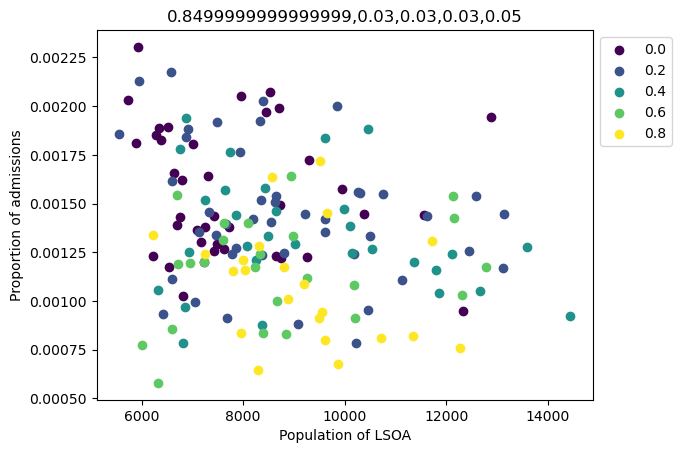

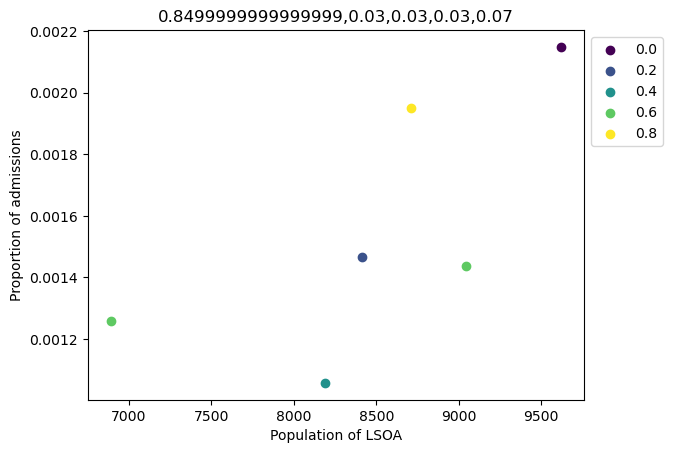

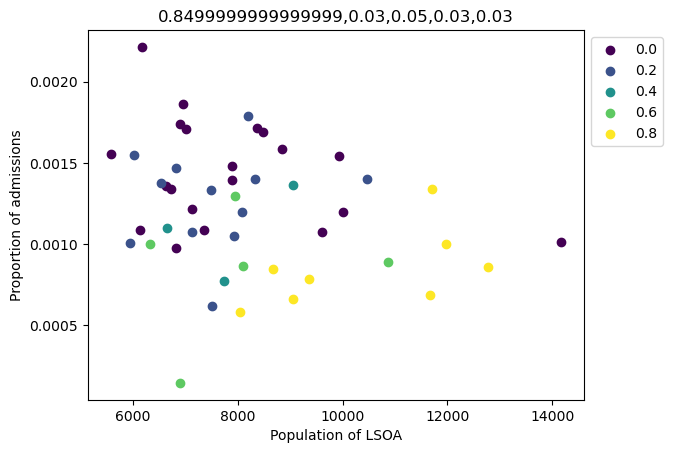

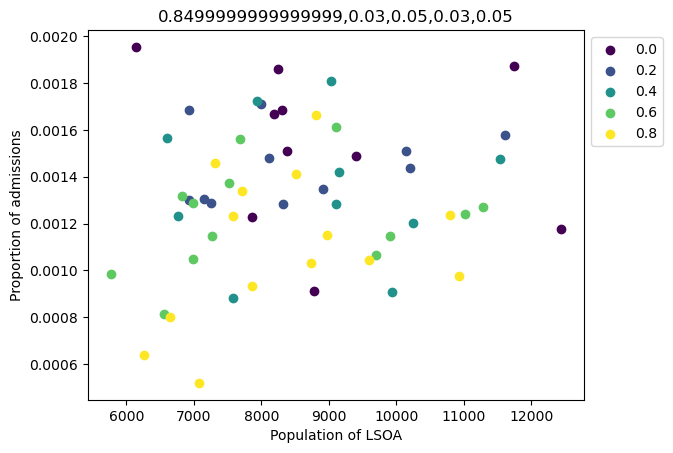

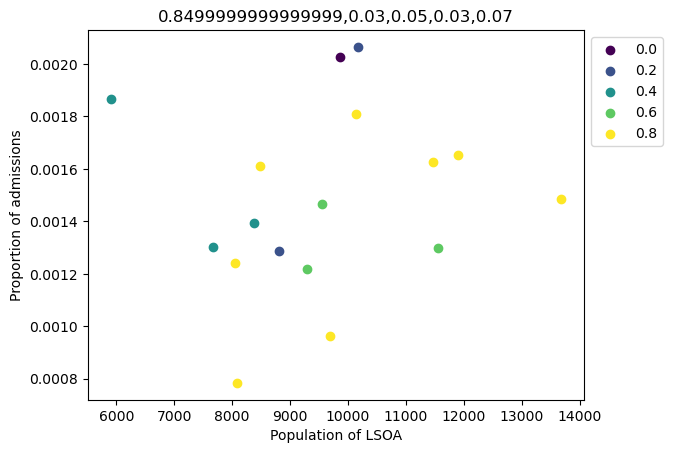

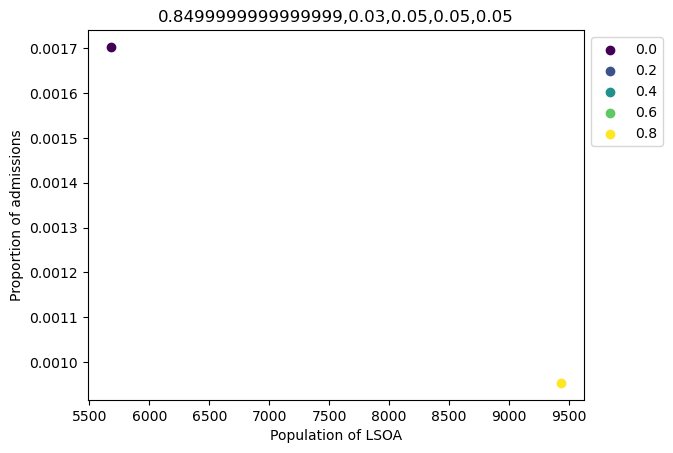

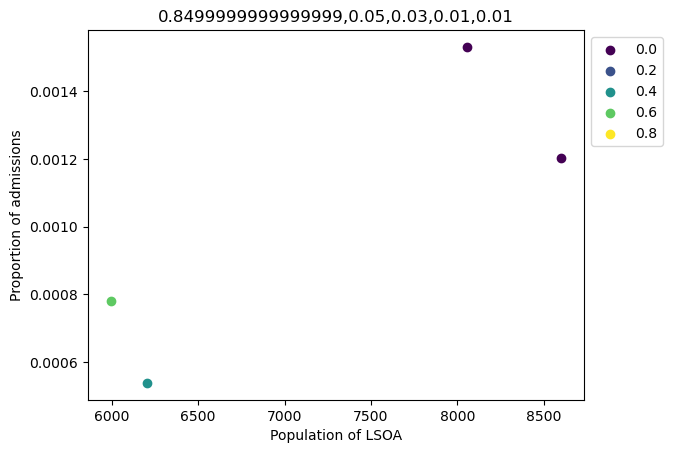

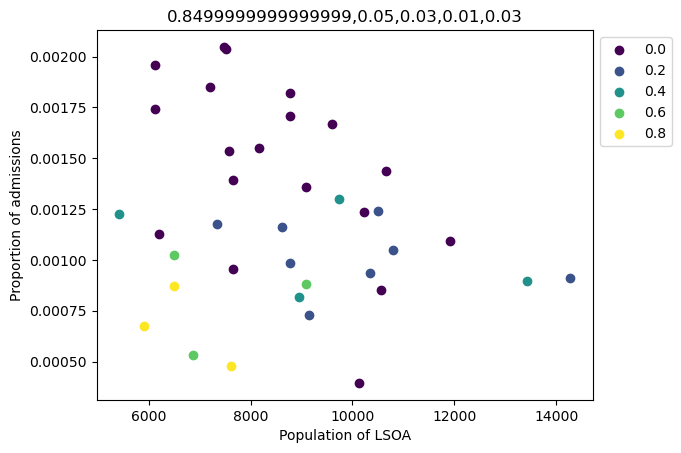

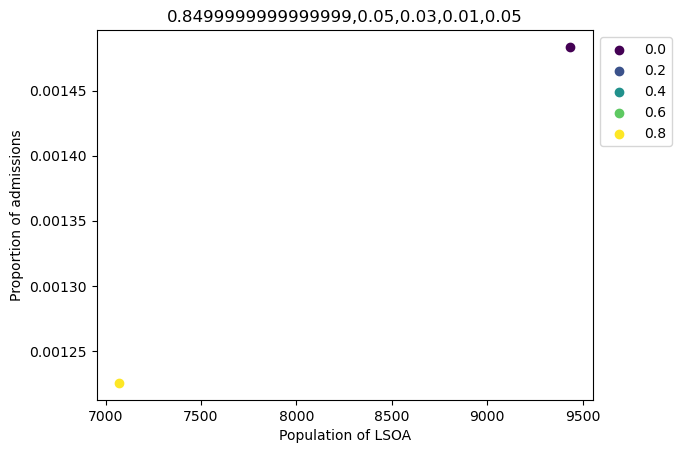

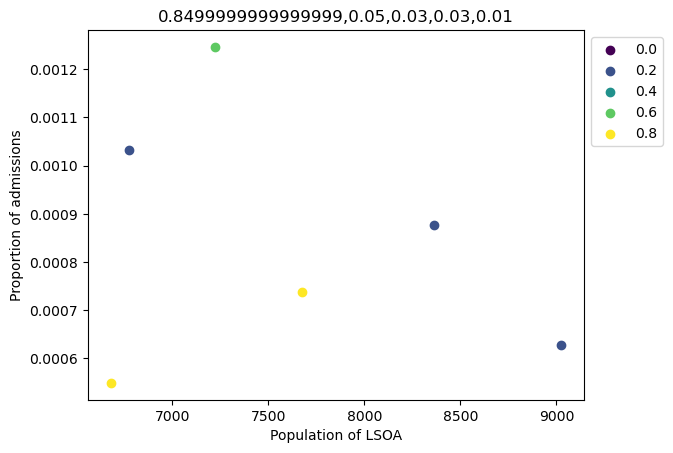

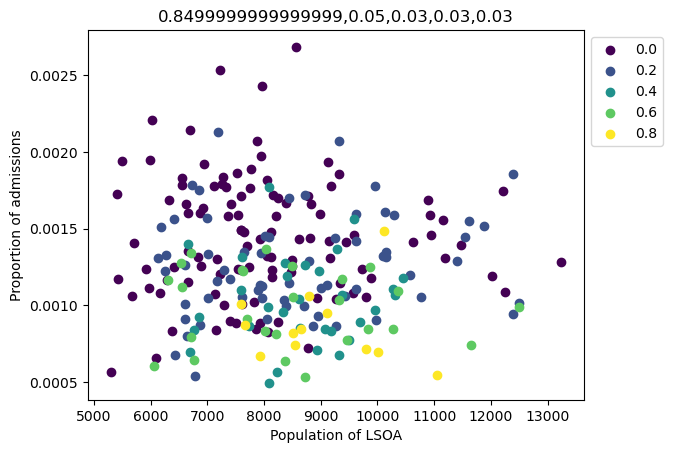

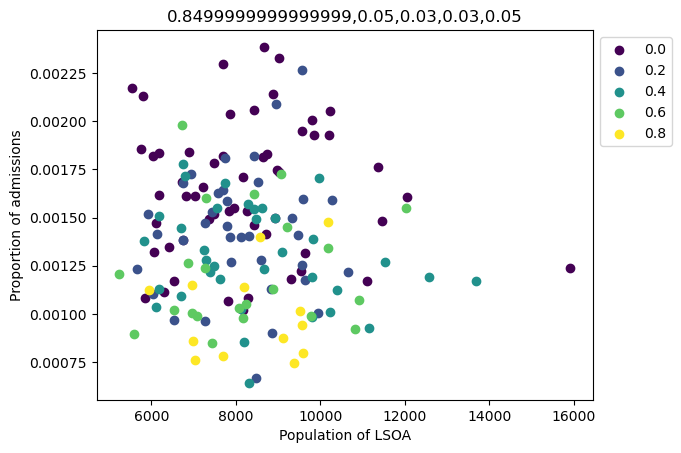

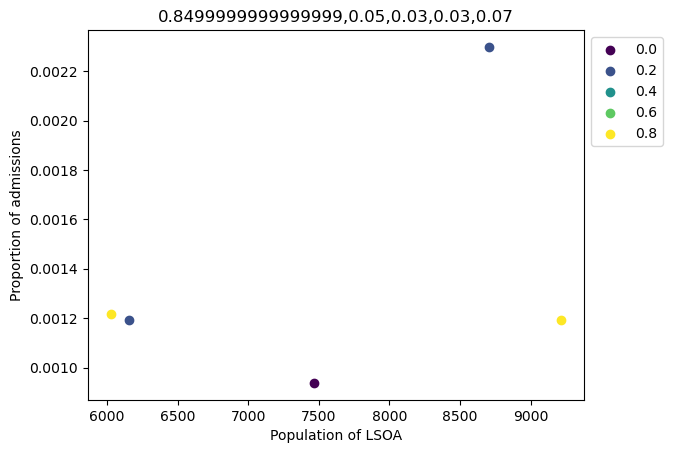

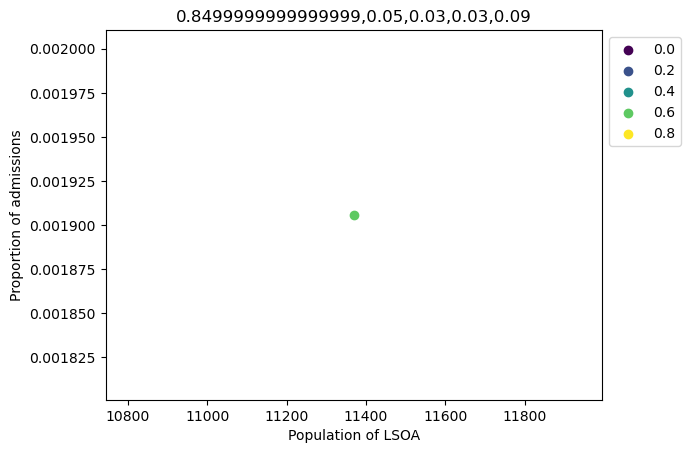

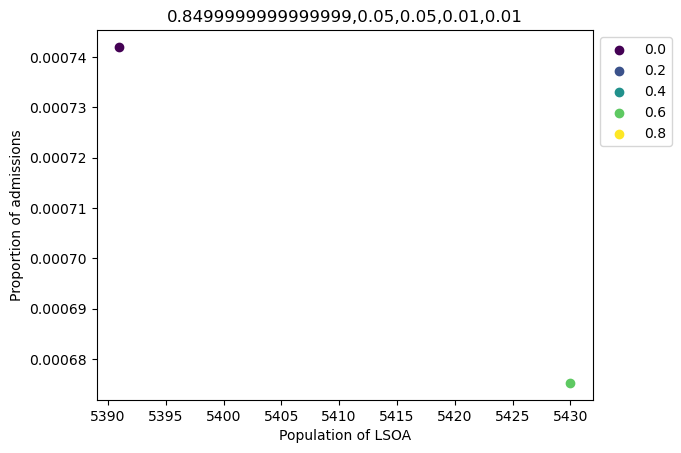

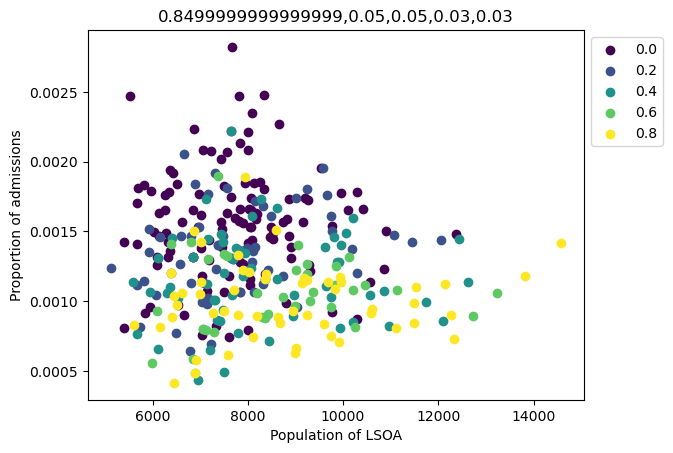

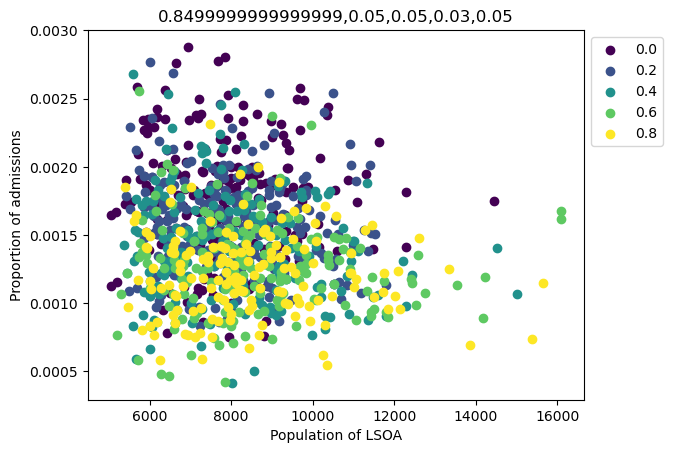

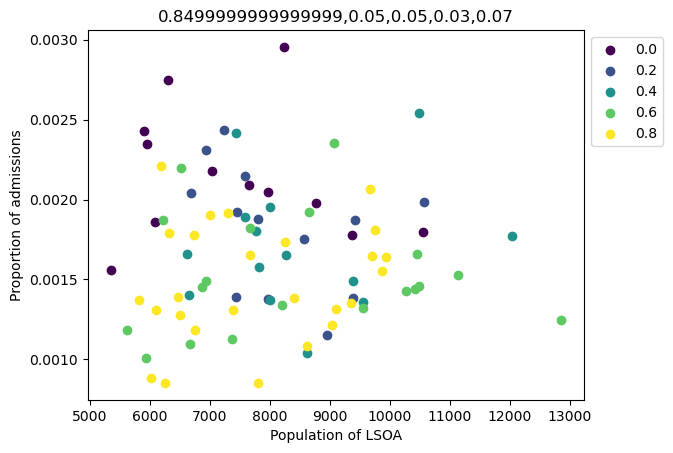

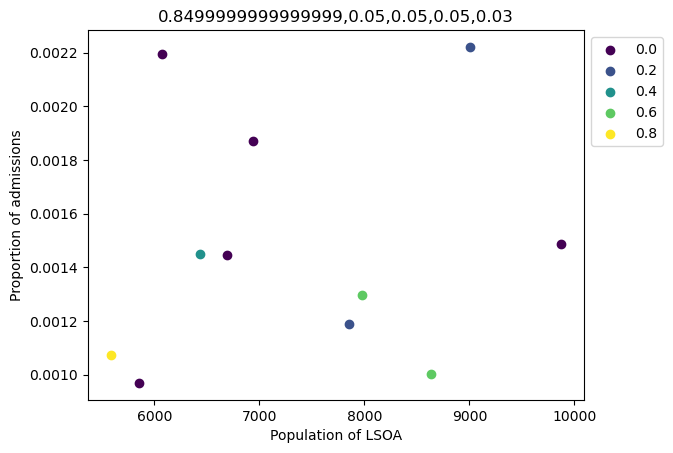

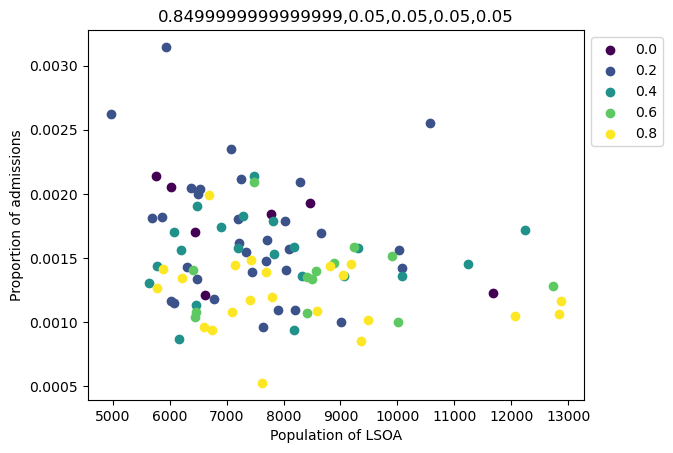

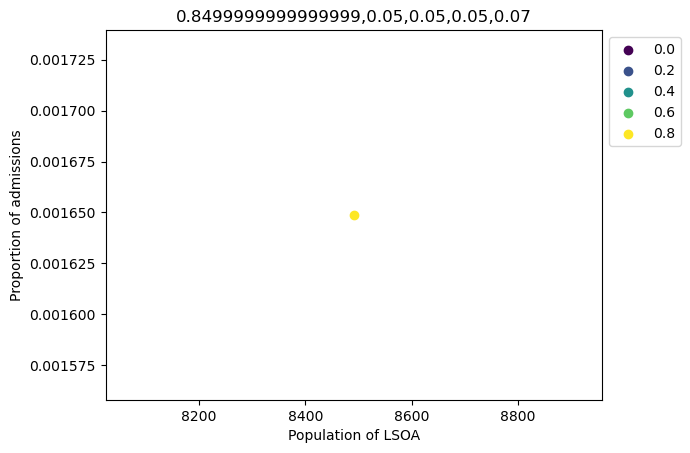

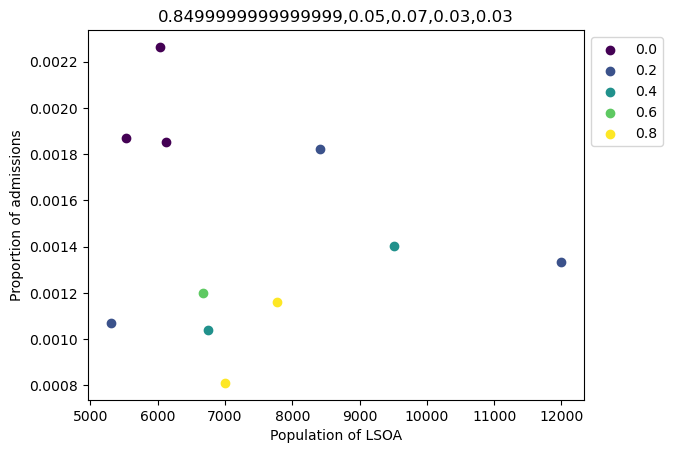

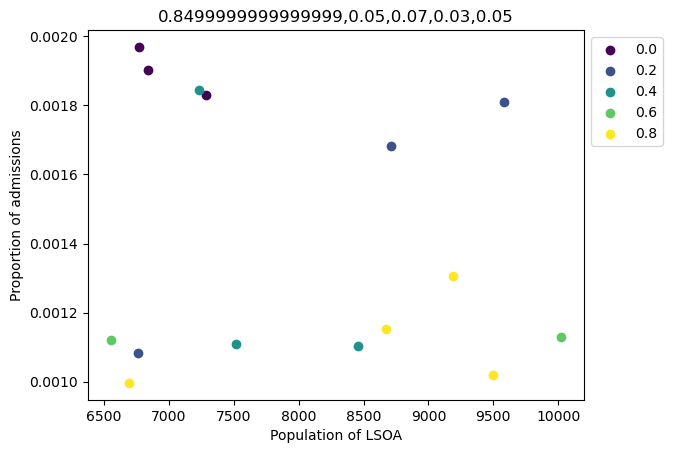

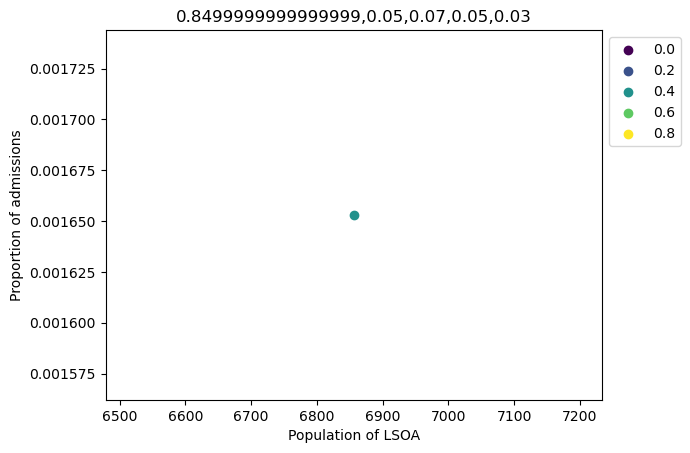

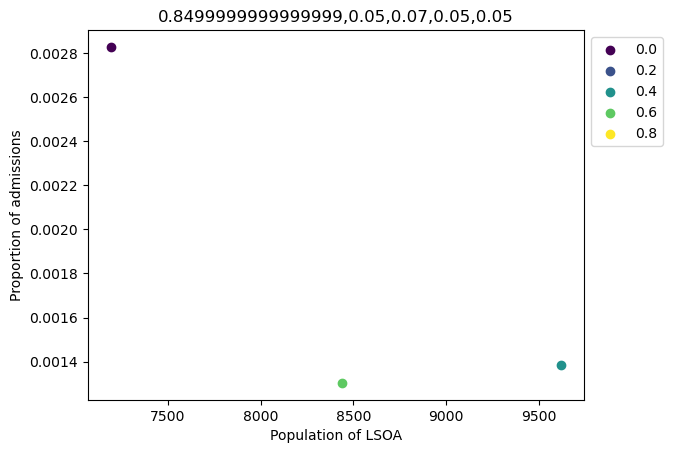

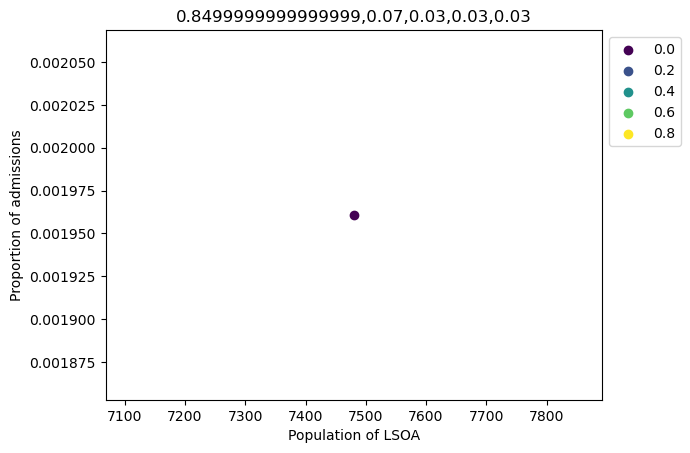

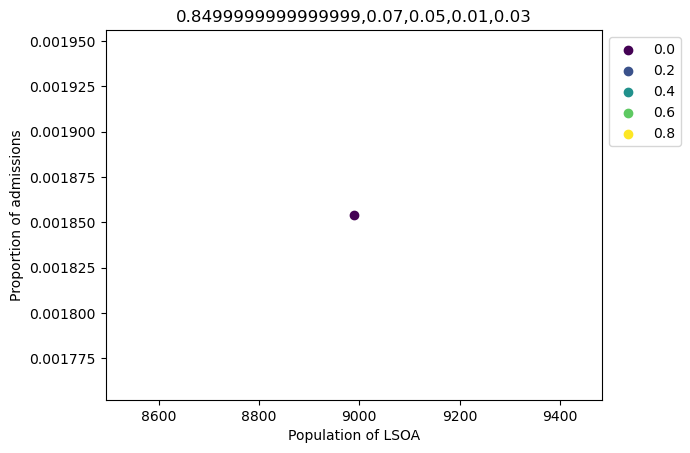

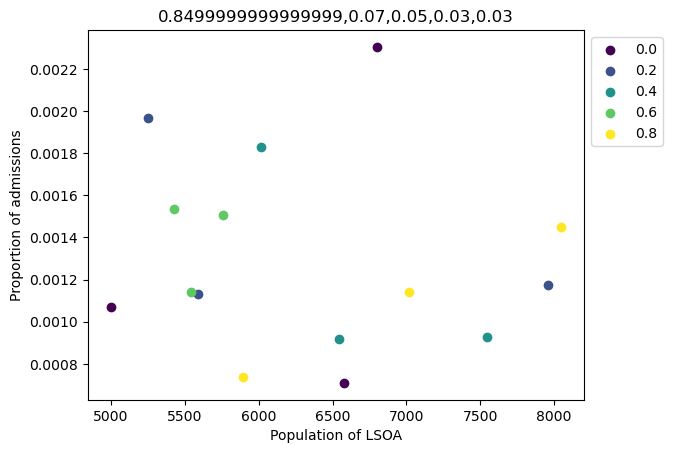

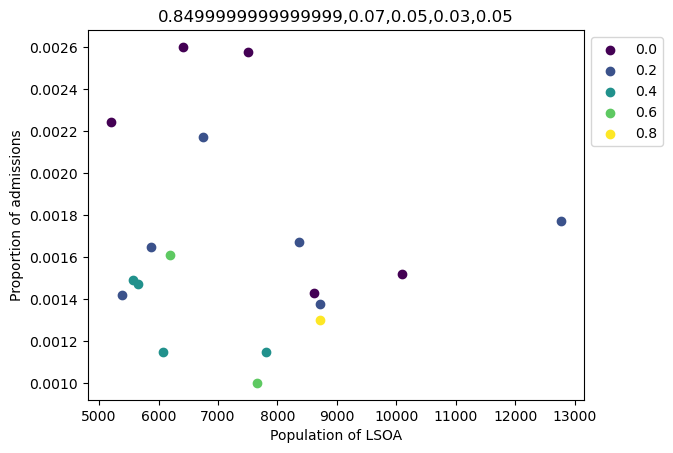

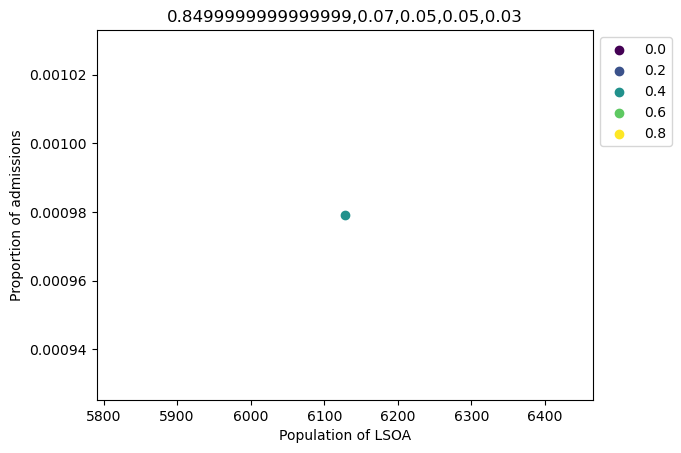

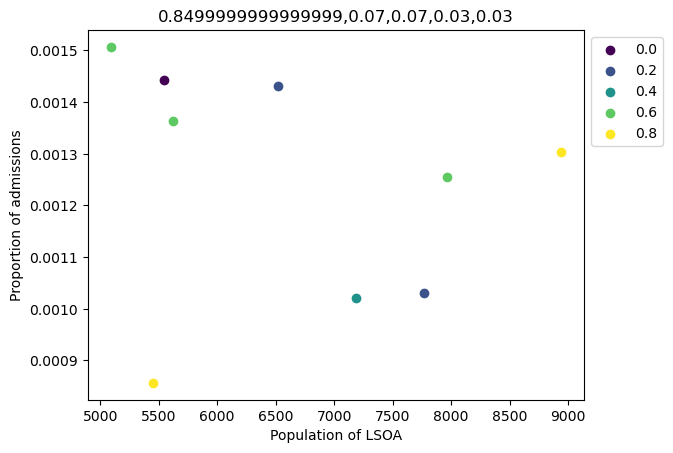

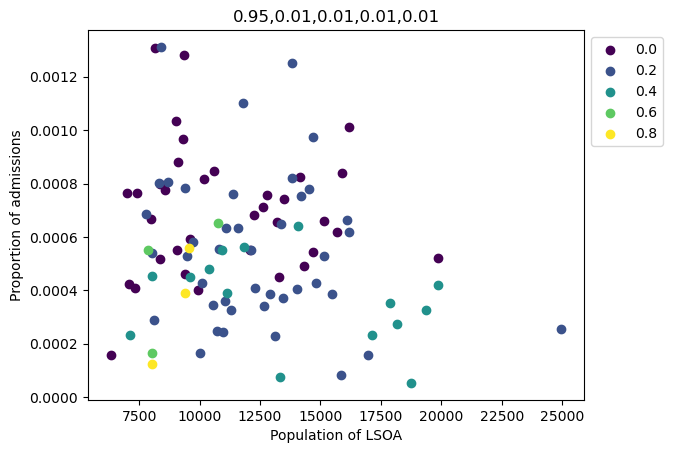

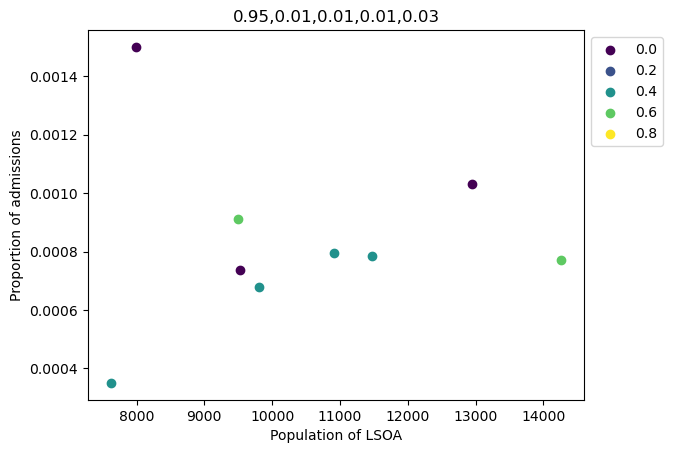

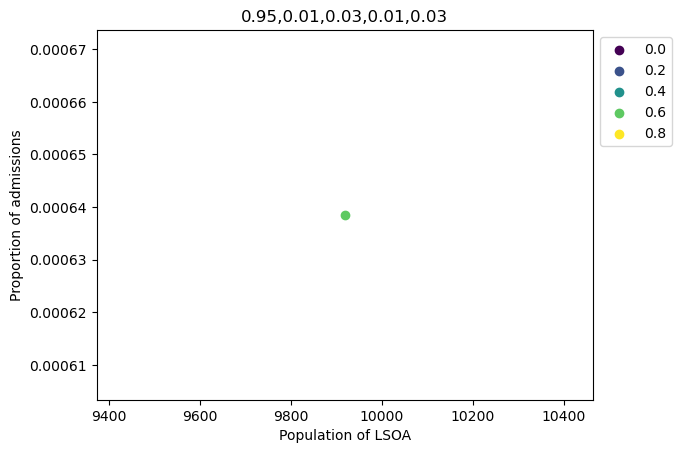

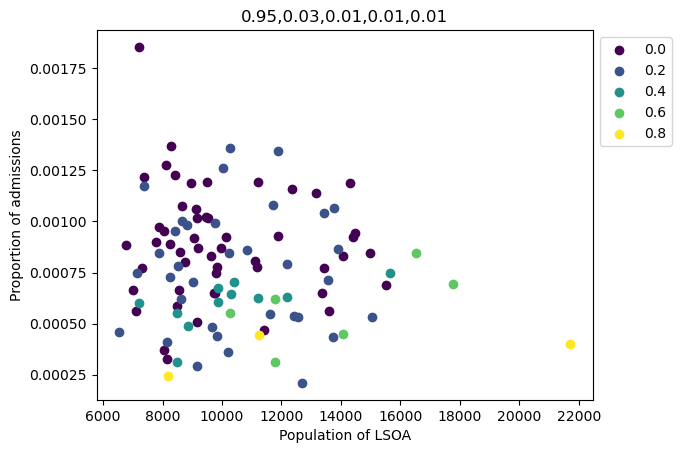

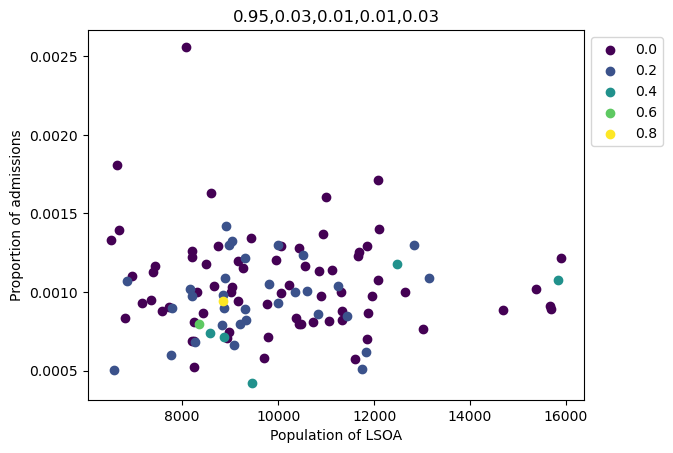

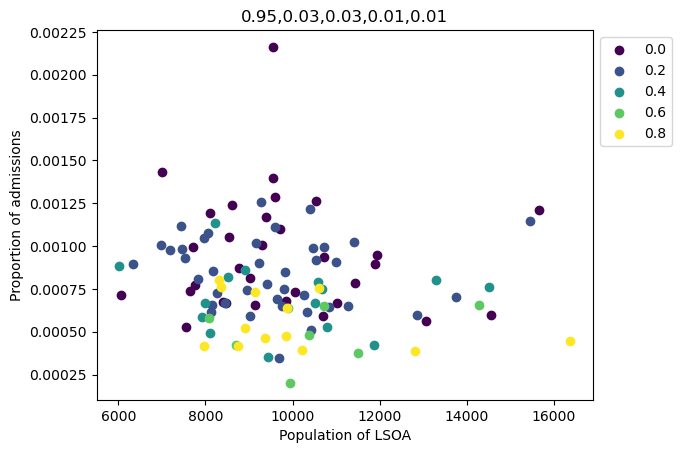

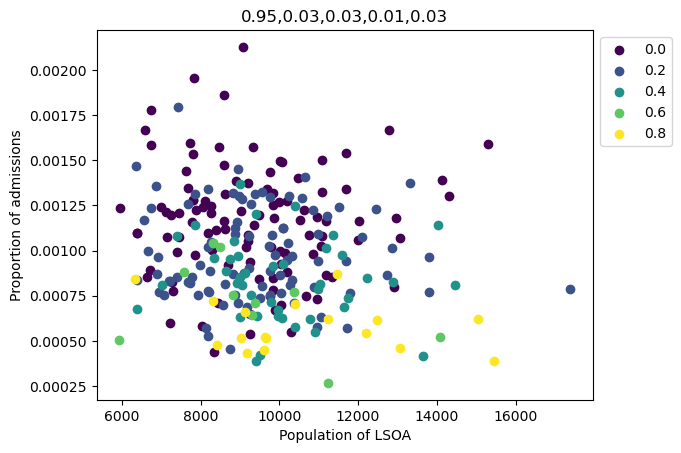

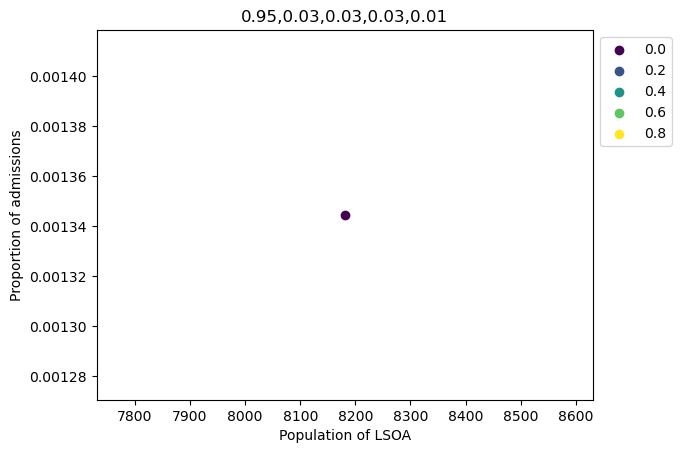

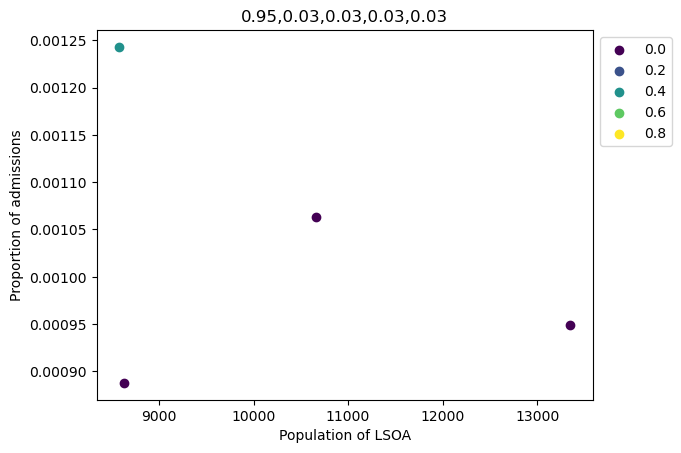

In [144]:
for combo in df_bin_mid_combo_n['combo']:
    bin_mid_combo = df_bin_mid_combo_n.filter(df_bin_mid_combo_n['combo'] == combo)[bin_mid_cols].to_numpy()[0]
    combo_str = ','.join([str(s) for s in bin_mid_combo])
    
    mask = (df_stats[bin_mid_cols].to_numpy() == bin_mid_combo).all(axis=1)
    df_here = df_stats.filter(mask)

    fig, ax = plt.subplots()

    for i, q in enumerate(quantile_min_list):
        df_q = df_here.filter(df_here['depriv_quantile_min'] == q)
        ax.scatter(df_q['All persons'], df_q['admissions_prop'], label=q, color=colours[i])
        
    ax.set_xlabel('Population of LSOA')
    ax.set_ylabel('Proportion of admissions')
    ax.set_title(combo_str)
    ax.legend(bbox_to_anchor=[1.0, 1.0], loc='upper left')
    plt.show()

In [135]:
list(bin_mid_combo)

[-42000.0, 0.07, 0.09, 0.09, 42000.0]

(array([88., 20.,  4.,  8.,  3.,  3.,  0.,  3.,  1.,  3.,  3.,  1.,  0.,
         2.,  0.,  1.,  2.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  2.,  0.,
         2.,  0.,  1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  1.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.]),
 array([   0.,   10.,   20.,   30.,   40.,   50.,   60.,   70.,   80.,
          90.,  100.,  110.,  120.,  130.,  140.,  150.,  160.,  170.,
         180.,  190.,  200.,  210.,  220.,  230.,  240.,  250.,  260.,
         270.,  280.,  290.,  300.,  310.,  320.,  330.,  340.,  350.,
         360.,  370.,  380.,  390.,  400.,  410.,  420.,  430.,  440.,
         450.,  460.,  470.,  480.,  490.,  500.,  510.,  520.,  530.,
        

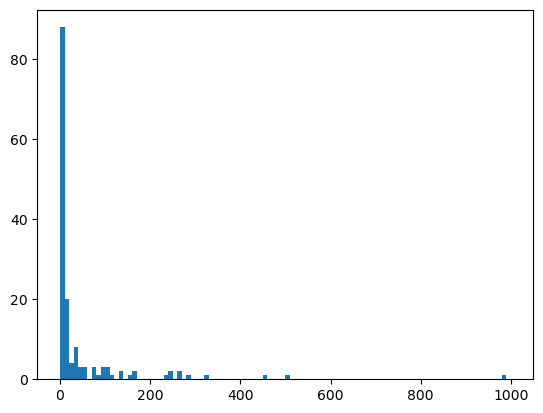

In [121]:
plt.hist(df_bin_mid_combo_n['n_combo'], bins=np.arange(0, 1010, 10))